# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 52     |  |
| :-------------|:-------------|
| Luuc Leclercq| 6578136 |
| Max Feijtes| 6498396 |
| Robert den Haan| 6512186 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Luuc', 'Max','Robert']

## Opdracht 1: Planning.

| Planning Groep: 52     |Tijdstip / Tijdspanne  |
|---|---|
| Sensor gekalibreerd | 12:00 |
| Meetopstelling getest | 14:00 |
| groep aanwezig 1| 10:45 - 12:30 |
| groep aanwezig 2| 13:30 - 15:30 |
| Pauze 1| 12:30 - 13:30 |
| Pauze 2| 15:30 - 15:45 |


## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

from scipy.optimize import curve_fit

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep 52
<img src="foto_4_kalibratieopstelling.jpeg" width="400">

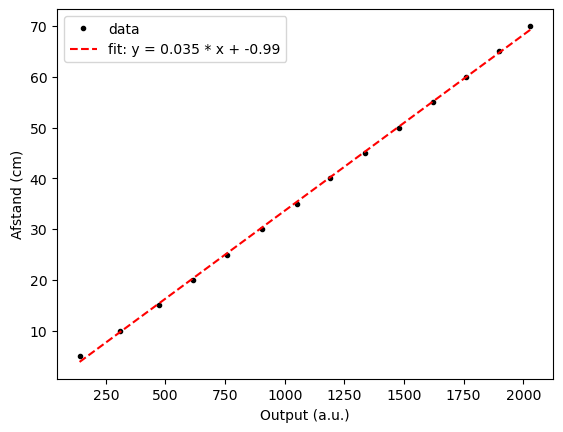

0.034612781102399626
-0.9894125858680405


In [3]:
# verwerk hier jullie kalibratiemetingen

output =  np.array([140, 310, 475, 615, 760, 903, 1050, 1190, 1335, 1480, 1620, 1760, 1900, 2030])
afstand_lineaal = np.array([5, 10, 15, 20, 25, 30, 35 ,40 ,45, 50, 55, 60, 65, 70])

def kalibratie_fit(x,a,b):
    return a*x + b

popt, pcov = curve_fit(kalibratie_fit, output, afstand_lineaal)
rc = popt[0]    
sys_fout = popt[1]

plt.figure()
plt.plot(output, afstand_lineaal, 'k.', label='data',)
plt.plot(output, kalibratie_fit(output, rc, sys_fout),  'r--', label='fit: y = {:.3f} * x + {:.2f}'.format(rc, sys_fout))
plt.xlabel('Output (a.u.)')
plt.ylabel('Afstand (cm)')
plt.legend()
plt.show()

print(rc)
print(sys_fout)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  41.8
1   0  30   0  20  42.2
2  40   0  30   0  41.5
3  30   0  20   0  41.0


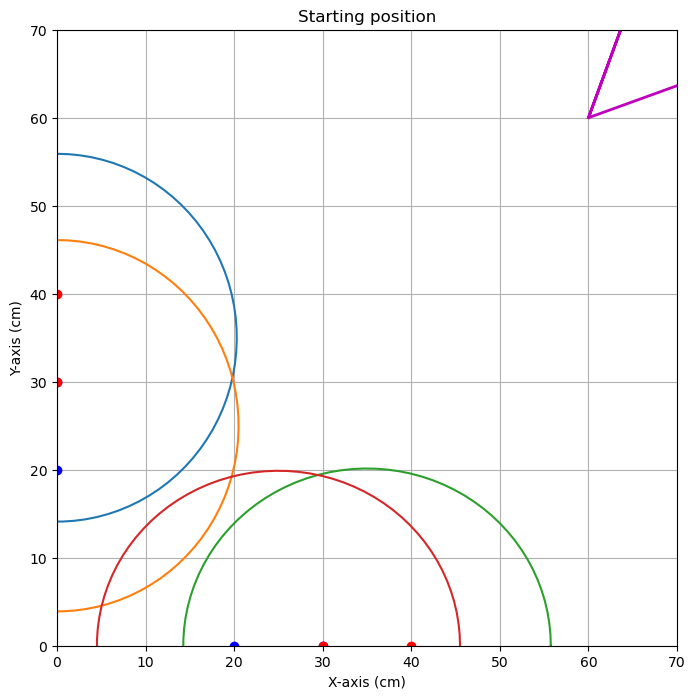


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=100.330


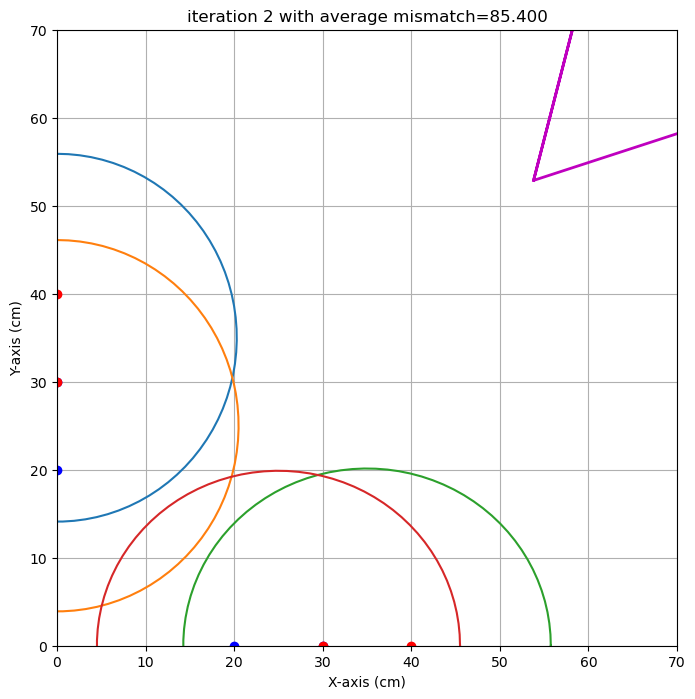

end iteration 2 with average mismatch=85.400


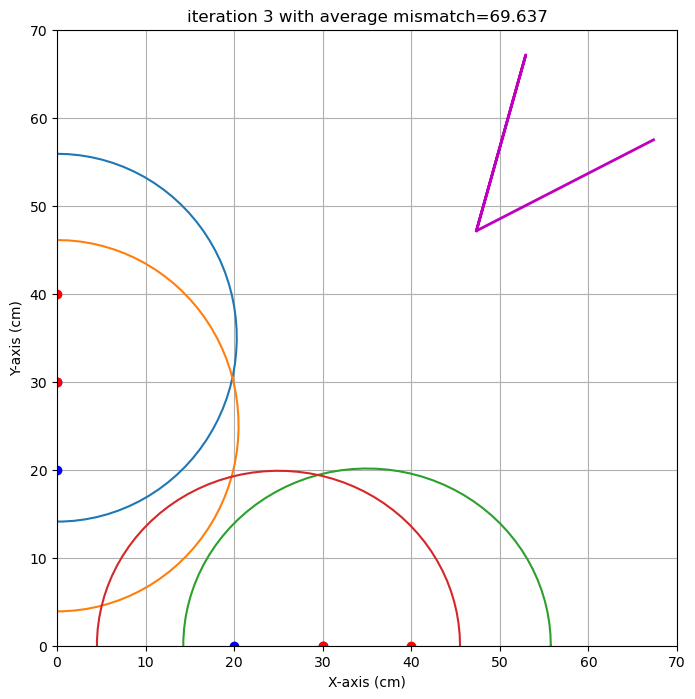

end iteration 3 with average mismatch=69.637


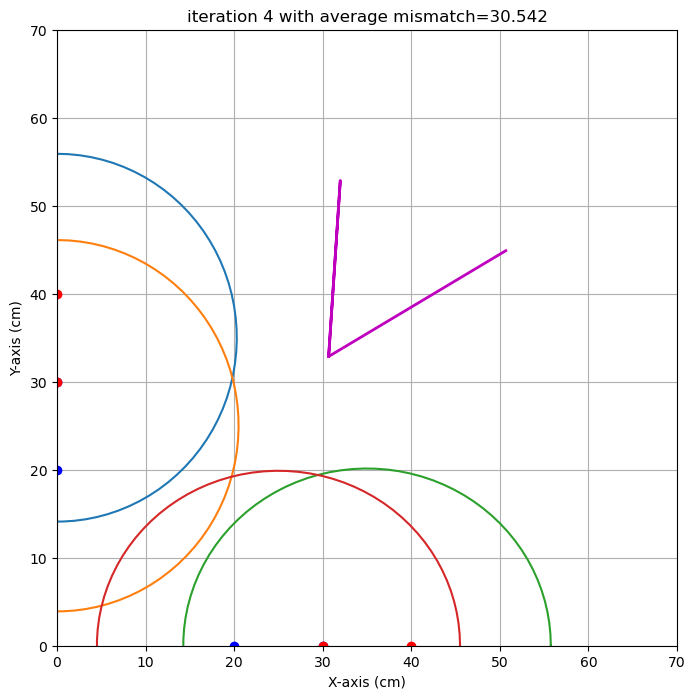

end iteration 4 with average mismatch=30.542


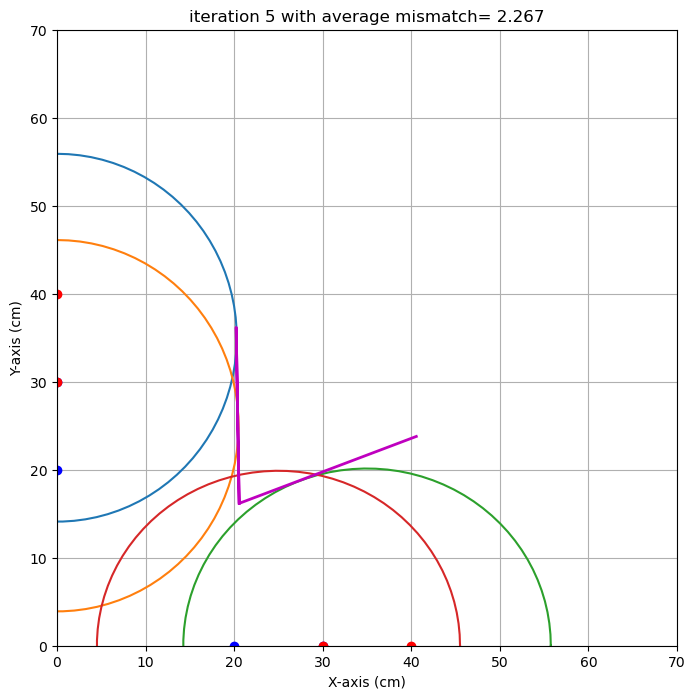

end iteration 5 with average mismatch= 2.267


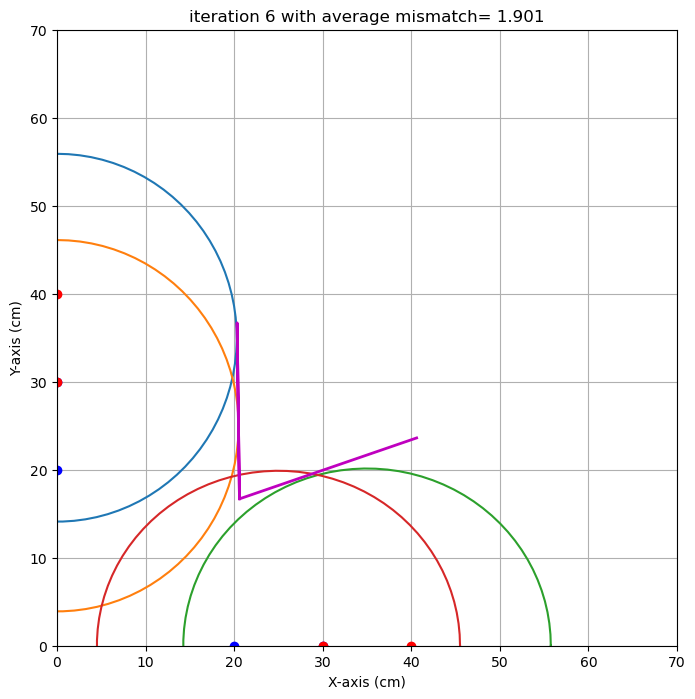

end iteration 6 with average mismatch= 1.901
end iteration 7 with average mismatch= 1.799
end iteration 8 with average mismatch= 1.687
end iteration 9 with average mismatch= 1.542


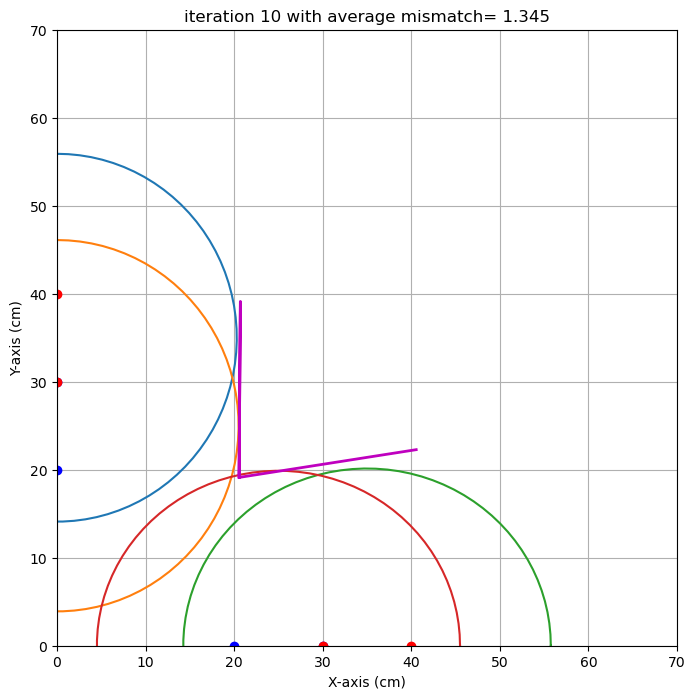

end iteration 10 with average mismatch= 1.345


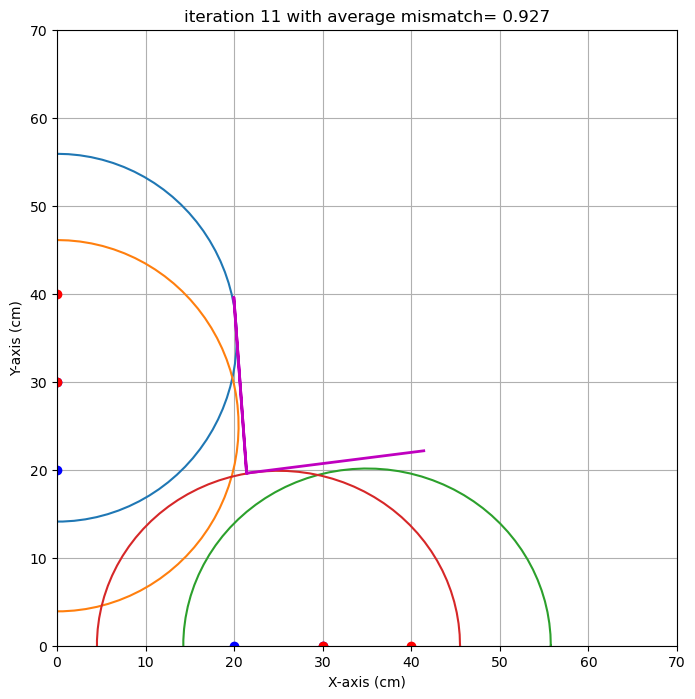

end iteration 11 with average mismatch= 0.927


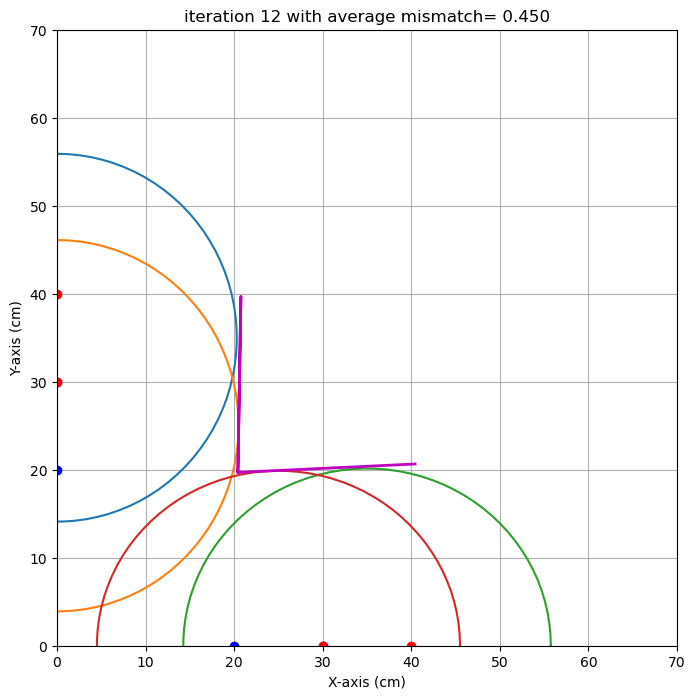

end iteration 12 with average mismatch= 0.450
end iteration 13 with average mismatch= 0.437
end iteration 14 with average mismatch= 0.435
end iteration 15 with average mismatch= 0.434


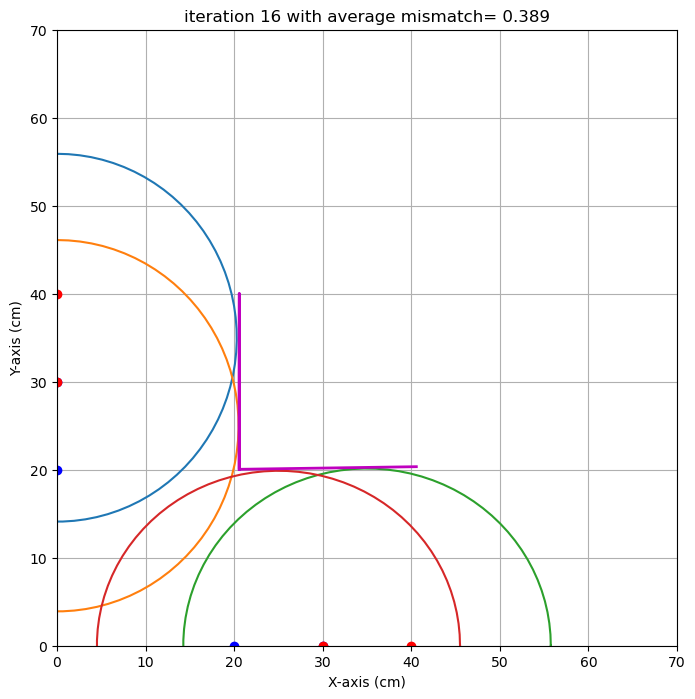

end iteration 16 with average mismatch= 0.389


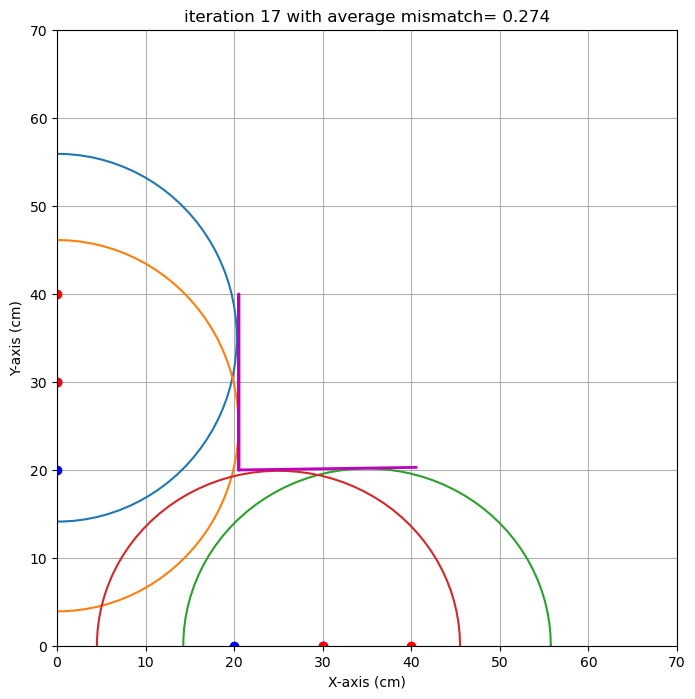

end iteration 17 with average mismatch= 0.274


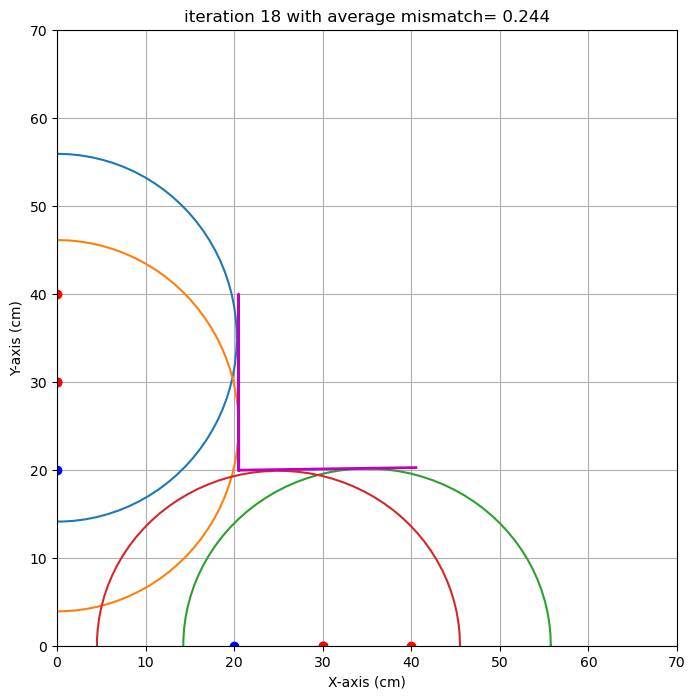

end iteration 18 with average mismatch= 0.244
end iteration 19 with average mismatch= 0.231
end iteration 20 with average mismatch= 0.228
end iteration 21 with average mismatch= 0.228
end iteration 22 with average mismatch= 0.228
end iteration 23 with average mismatch= 0.228
end iteration 24 with average mismatch= 0.228
end iteration 25 with average mismatch= 0.228
end iteration 26 with average mismatch= 0.228
end iteration 27 with average mismatch= 0.228
end iteration 28 with average mismatch= 0.228
end iteration 29 with average mismatch= 0.228
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.228
###############################################################################
end of iteration  30
Best alpha=   0.84 with uncertainty=   0.95
Best beta =  -0.04 with uncertainty=   0.92
Best x0   =  20.49 with uncertainty=   0.33
Best y0   =  19.93 with uncertainty

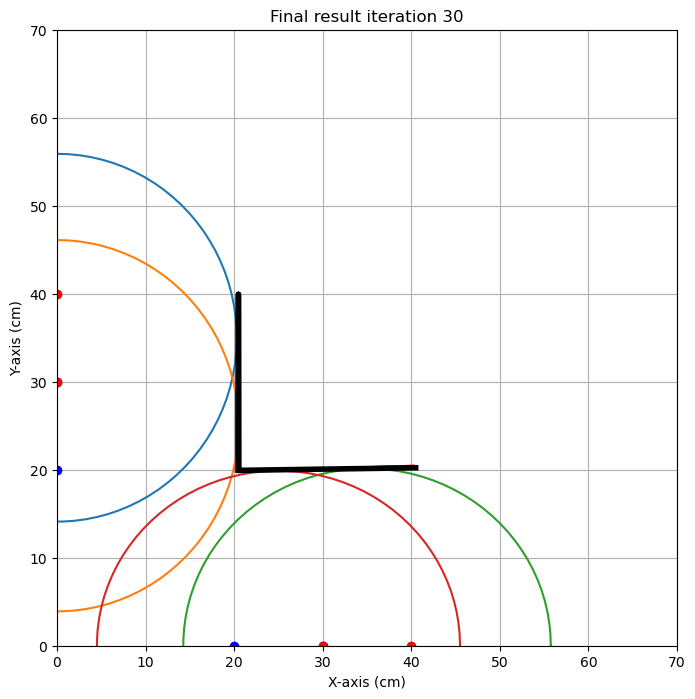

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,41.8],
    [0,30,0,20,42.2],
    #[0,10,0,20,46.6], ongeldig
    [40,0,30,0,41.5],
    [30,0,20,0,41.0],
    #[10,0,20,0,45.7], ongeldig
    #[10,0,0,10,49.0]   ongeldig
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 20.5 cm met een standaardafwijking van 0.3 cm 
y0: 19.9 cm met een standaardafwijking van 0.2 cm 
alpha: 0.8 graden met een standaardafwijking van 0.9 graad 
beta: -0.0 graden met een standaardafwijking van 0.9 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Max]
<img src="foto_1.jpeg" width="400">

#### algoritme [Luuc]
<img src="foto_2.jpeg" width="400">

#### algoritme [Robert]
<img src="foto_3.jpeg" width="400">

In [6]:
meting = 47.7
afstand_tussen_sensoren = 10

m = np.sqrt((meting/2)**2 - (afstand_tussen_sensoren/2)**2)
print(m)

23.320002144082235


## Opdracht 6: Test iteratie 0.

Bij de eerste test iteratie 0 hebben we een te scherpe hoek alfa gebruikt. Daarom hebben we later voor een minder scherpe hoek gekozen. De TA zei dat we maar 1 algoritme opnieuw hoefden te testen, wegens de tijd.

In [17]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':38,  #zelf aanvullen,
           'y0':21.5,  #zelf aanvullen,
           'alpha':15, #zelf aanvullen,
           'beta':10,}  #zelf aanvullen
          
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Luuc' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # [0,30,0,20, ongeldig]  
    [0,60,0,70,87],
    [0,45,0,55,86.8],
    #[30,0,20,0, ongeldig],
    [60,0,70,0,91.7],
    [55,0,45,0,82]
    ]),
       'Max' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[ #met te scherpe hoek
    #[30,0,40,0, ongeldig]  
    [50,0,60,0,86.7],
    [0,50,0,60,87.2],
    [55,0,65,0, 89],
    [0,55,0,65,87.5]
    ]),
       'Robert' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # [30,0,40,0, ongeldig]  
    [50,0,60,0,50.5],
    [0,41,0,31,81.2],
    [55,0,45,0,47.7],
    [0,26,0,36,79.5]
    ])
      }

## Opdracht 7: Evaluatie.

Luuc
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  60   0  70  87.0
1   0  45   0  55  86.8
2  60   0  70   0  91.7
3  55   0  45   0  82.0


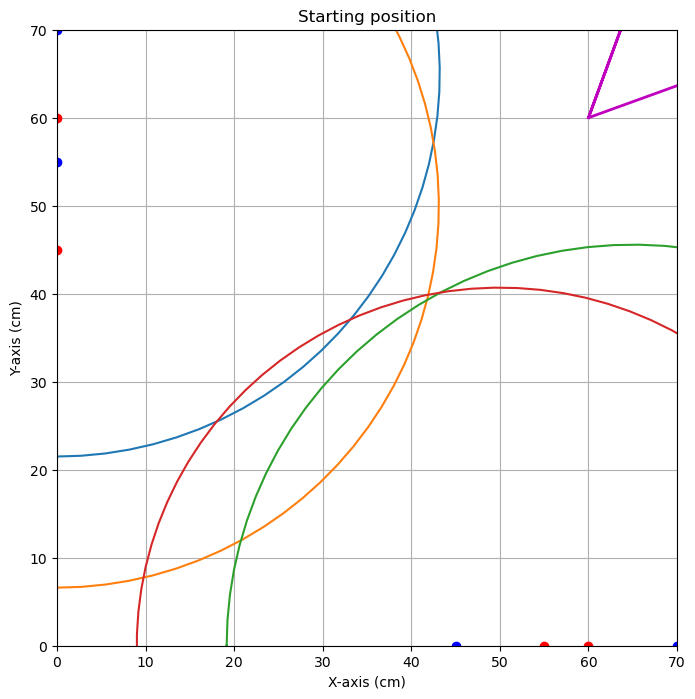


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=40.060


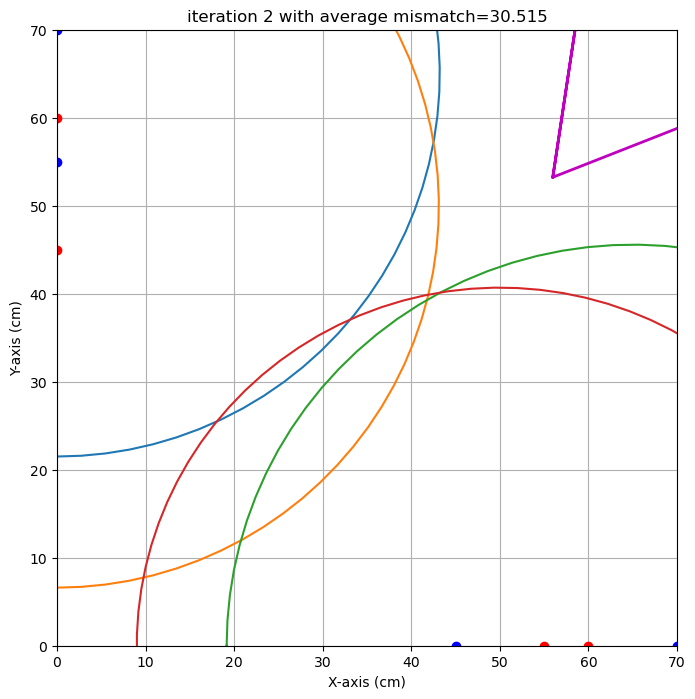

end iteration 2 with average mismatch=30.515


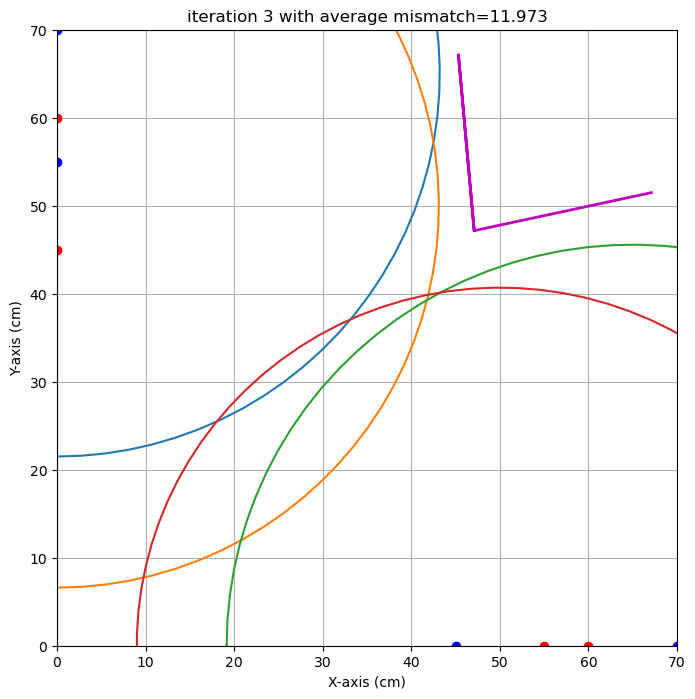

end iteration 3 with average mismatch=11.973


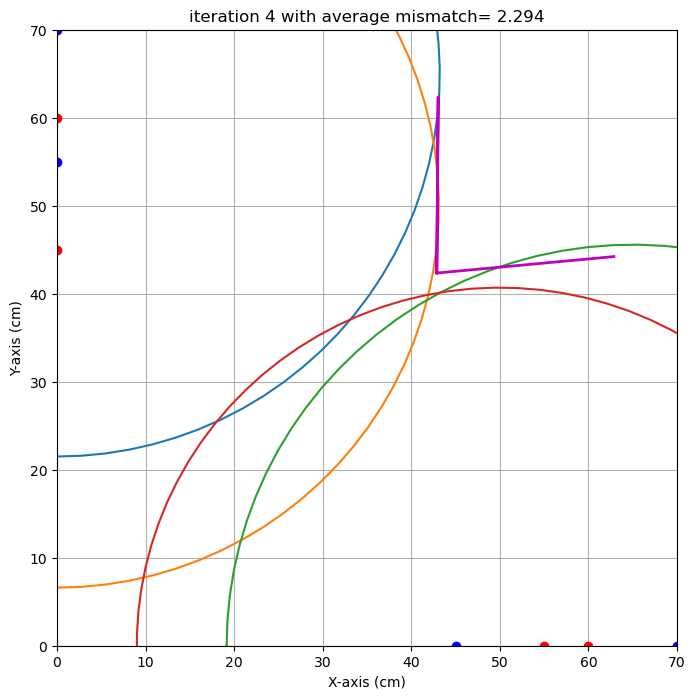

end iteration 4 with average mismatch= 2.294
end iteration 5 with average mismatch= 2.294
end iteration 6 with average mismatch= 2.178
end iteration 7 with average mismatch= 1.976
end iteration 8 with average mismatch= 1.905
end iteration 9 with average mismatch= 1.859
end iteration 10 with average mismatch= 1.859
end iteration 11 with average mismatch= 1.859
end iteration 12 with average mismatch= 1.750
end iteration 13 with average mismatch= 1.750
end iteration 14 with average mismatch= 1.750
end iteration 15 with average mismatch= 1.750
end iteration 16 with average mismatch= 1.659
end iteration 17 with average mismatch= 1.652
end iteration 18 with average mismatch= 1.652
end iteration 19 with average mismatch= 1.652
end iteration 20 with average mismatch= 1.652
end iteration 21 with average mismatch= 1.652
end iteration 22 with average mismatch= 1.652
end iteration 23 with average mismatch= 1.652
end iteration 24 with average mismatch= 1.652
end iteration 25 with average mismatch= 

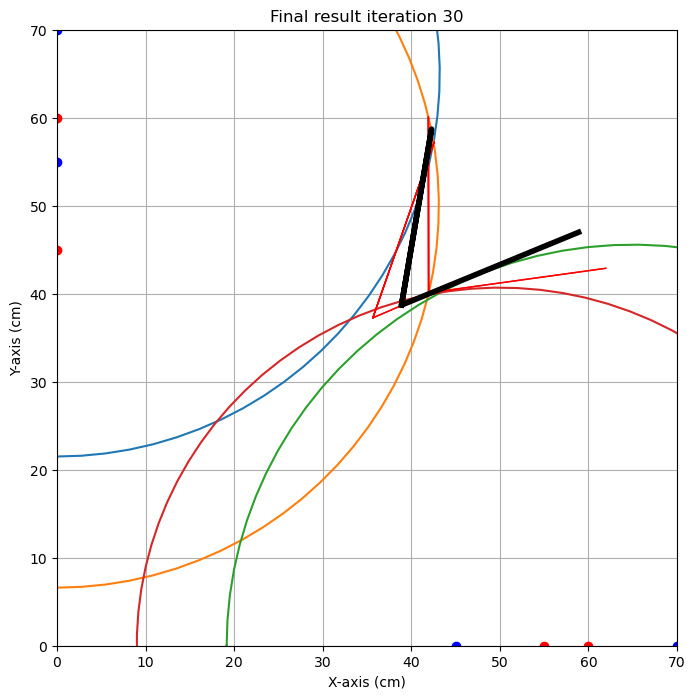

{'alpha': np.float64(22.482678372393416), 'alpha_eps': np.float64(14.548701871423368), 'beta': np.float64(9.63948077033942), 'beta_eps': np.float64(9.690322431931492), 'x0': np.float64(38.88718178181922), 'x0_eps': np.float64(3.228524075697692), 'y0': np.float64(38.7067940251267), 'y0_eps': np.float64(1.4442914542984298)}
Max
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  60   0  86.7
1   0  50   0  60  87.2
2  55   0  65   0  89.0
3   0  55   0  65  87.5


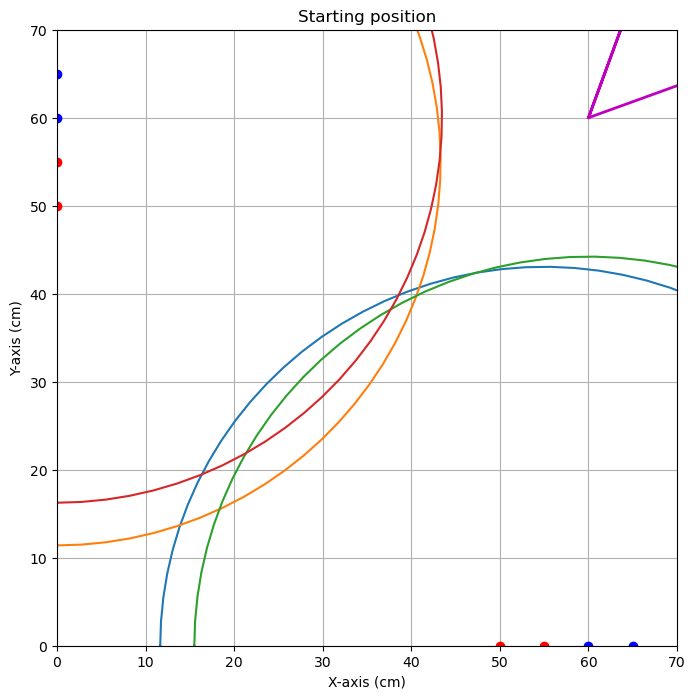


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=38.555


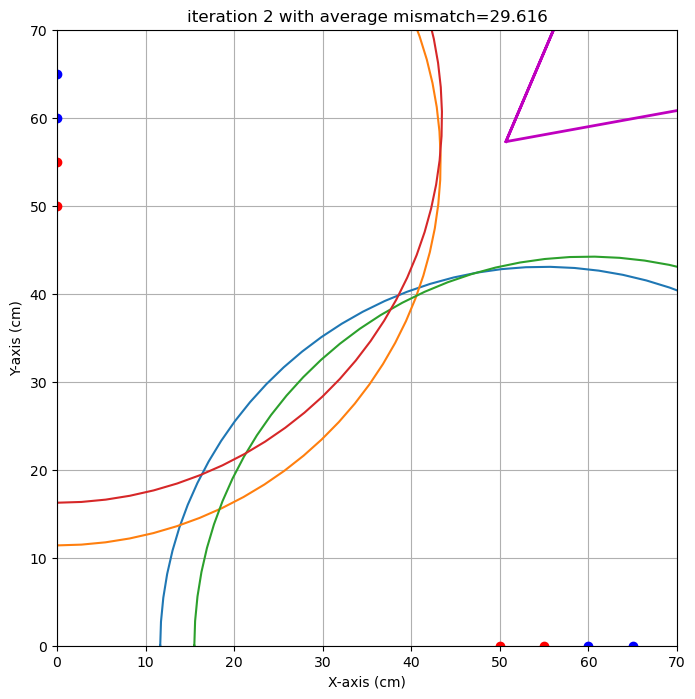

end iteration 2 with average mismatch=29.616


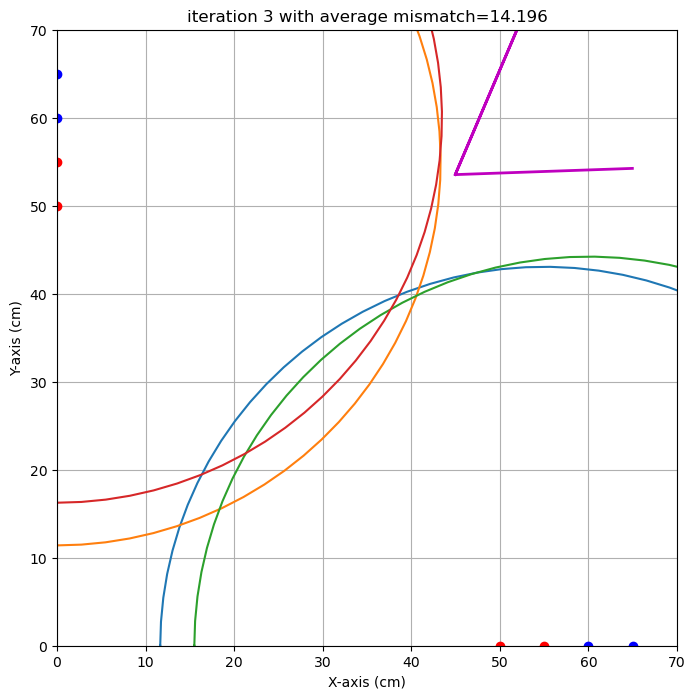

end iteration 3 with average mismatch=14.196


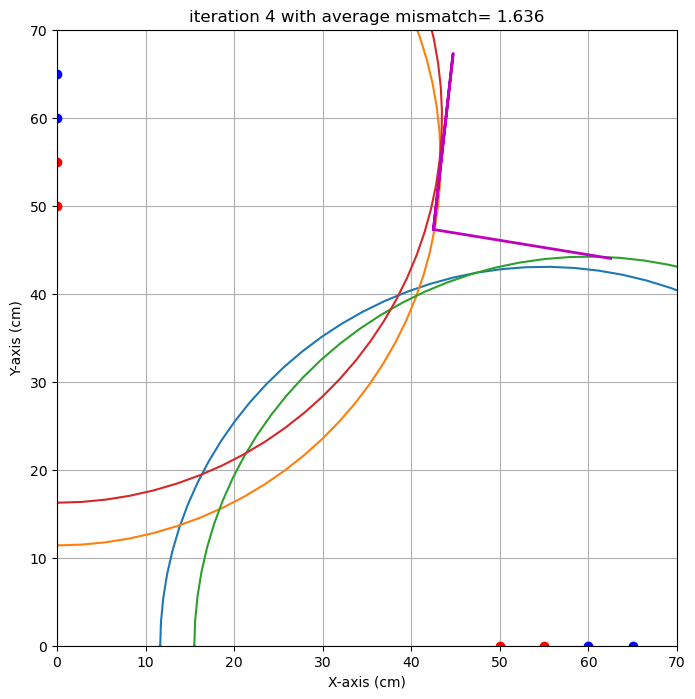

end iteration 4 with average mismatch= 1.636


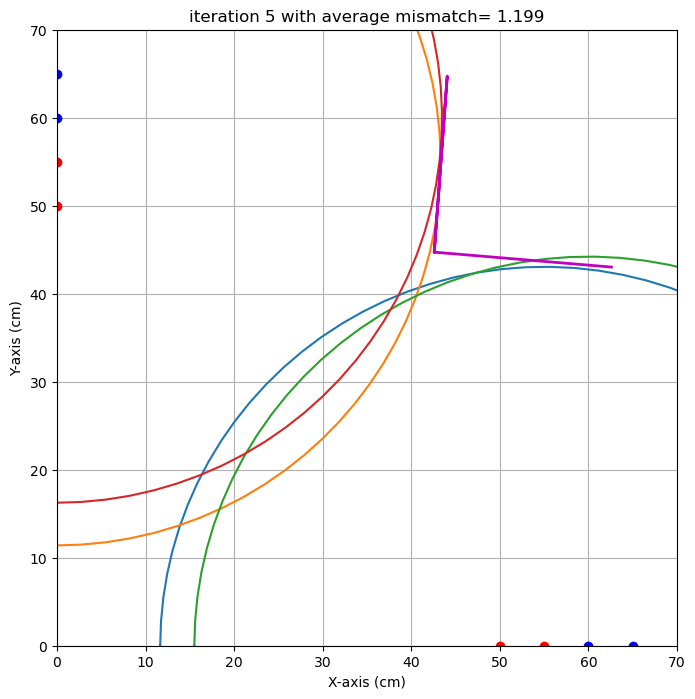

end iteration 5 with average mismatch= 1.199


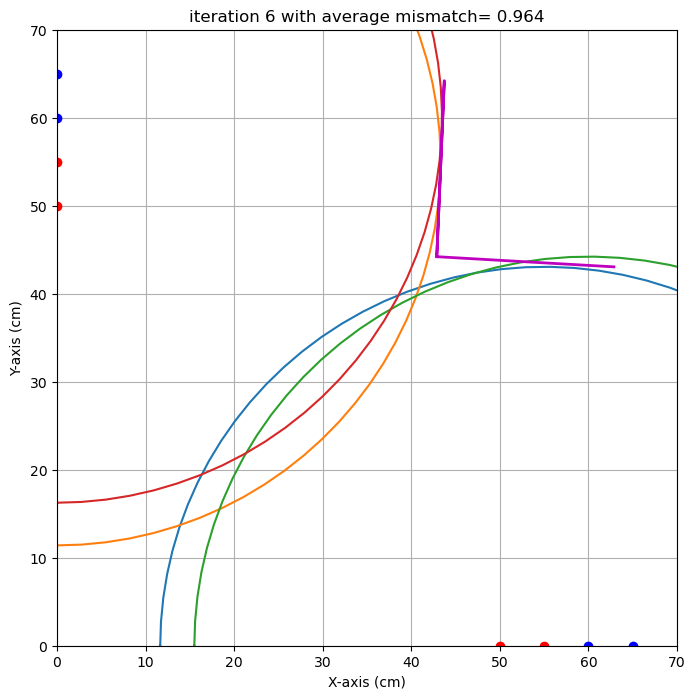

end iteration 6 with average mismatch= 0.964
end iteration 7 with average mismatch= 0.915


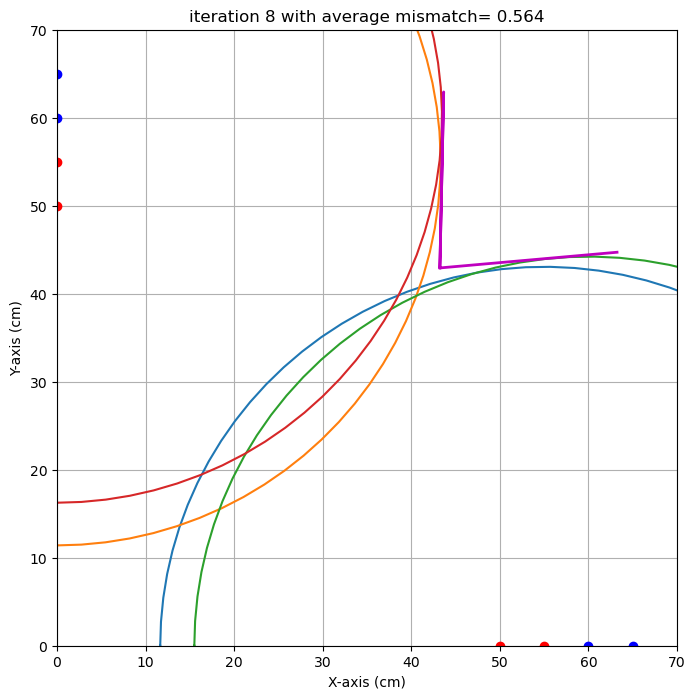

end iteration 8 with average mismatch= 0.564
end iteration 9 with average mismatch= 0.549
end iteration 10 with average mismatch= 0.502
end iteration 11 with average mismatch= 0.502


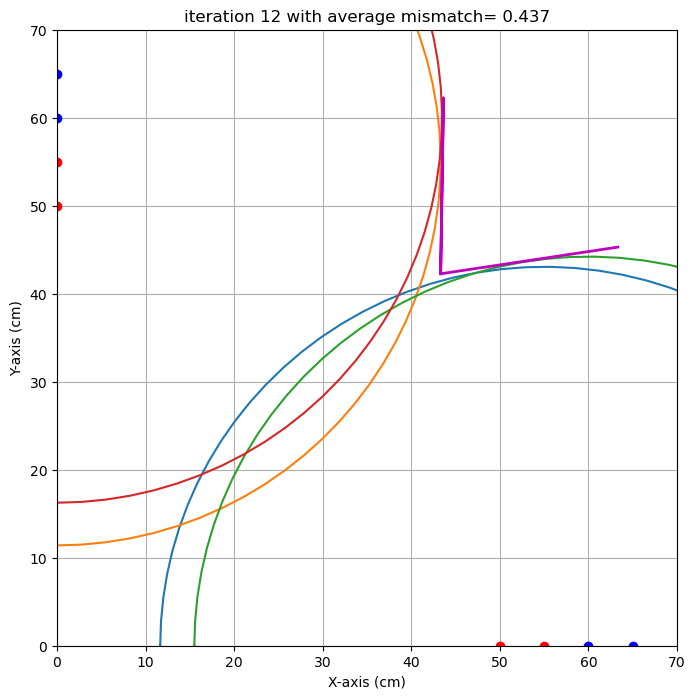

end iteration 12 with average mismatch= 0.437


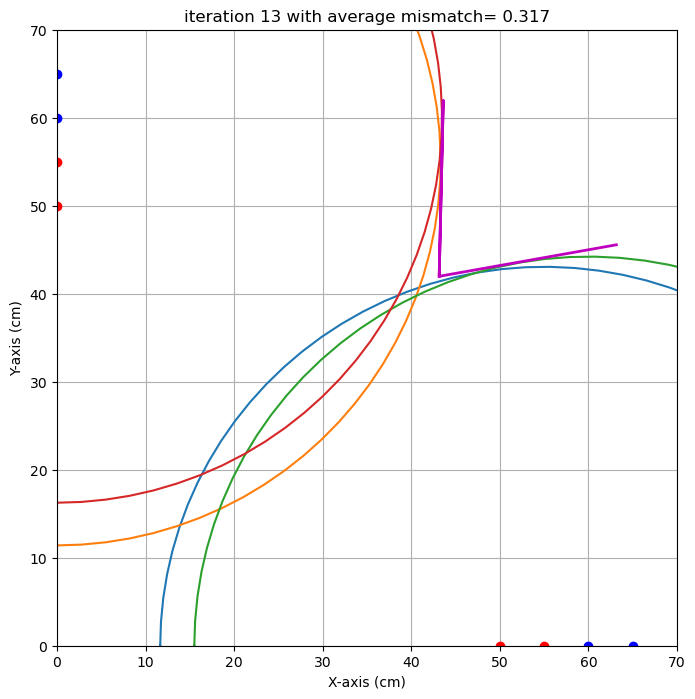

end iteration 13 with average mismatch= 0.317


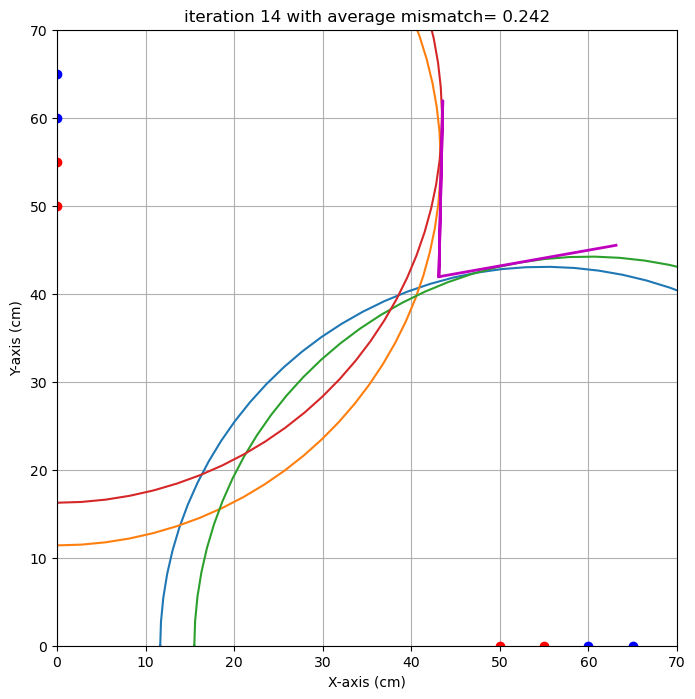

end iteration 14 with average mismatch= 0.242


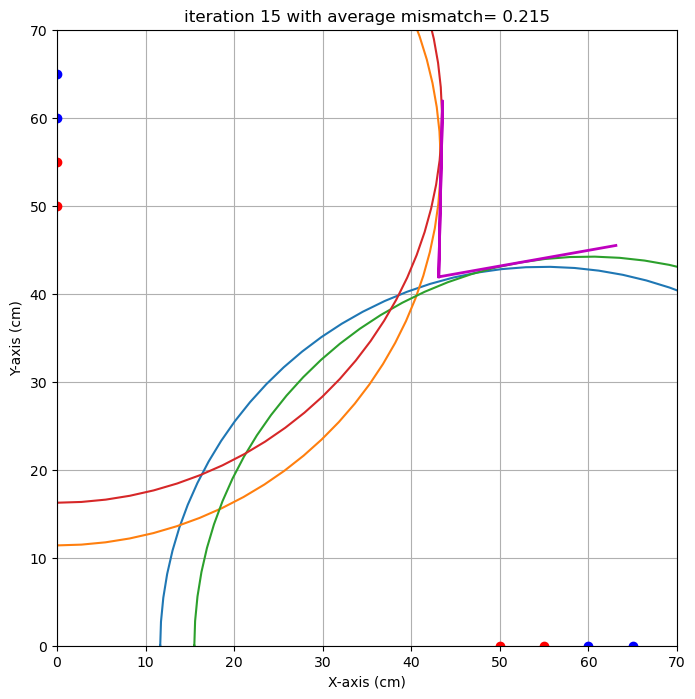

end iteration 15 with average mismatch= 0.215
end iteration 16 with average mismatch= 0.200
end iteration 17 with average mismatch= 0.198
end iteration 18 with average mismatch= 0.198
end iteration 19 with average mismatch= 0.198
end iteration 20 with average mismatch= 0.198
end iteration 21 with average mismatch= 0.198
end iteration 22 with average mismatch= 0.198
end iteration 23 with average mismatch= 0.198
end iteration 24 with average mismatch= 0.198
end iteration 25 with average mismatch= 0.198
end iteration 26 with average mismatch= 0.198
end iteration 27 with average mismatch= 0.198
end iteration 28 with average mismatch= 0.198
end iteration 29 with average mismatch= 0.198
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.198
###############################################################################
end of iteration  30
Best alpha=  10.11 with uncertainty=   4.64
Best beta 

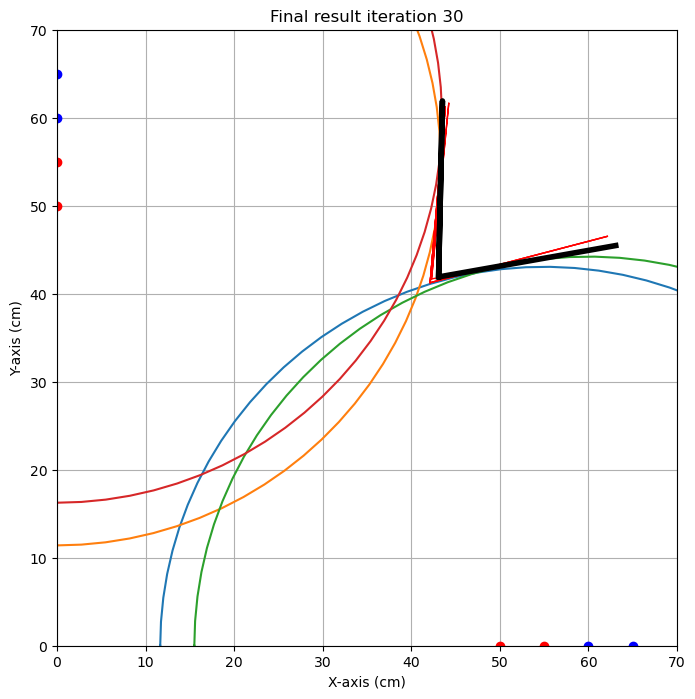

{'alpha': np.float64(10.111328886841953), 'alpha_eps': np.float64(4.63963315705972), 'beta': np.float64(1.2432389426276569), 'beta_eps': np.float64(4.329682556888131), 'x0': np.float64(43.07948419356779), 'x0_eps': np.float64(0.9522435858948484), 'y0': np.float64(41.907170934956554), 'y0_eps': np.float64(0.6540518825767094)}
Robert
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  60   0  50.5
1   0  41   0  31  81.2
2  55   0  45   0  47.7
3   0  26   0  36  79.5


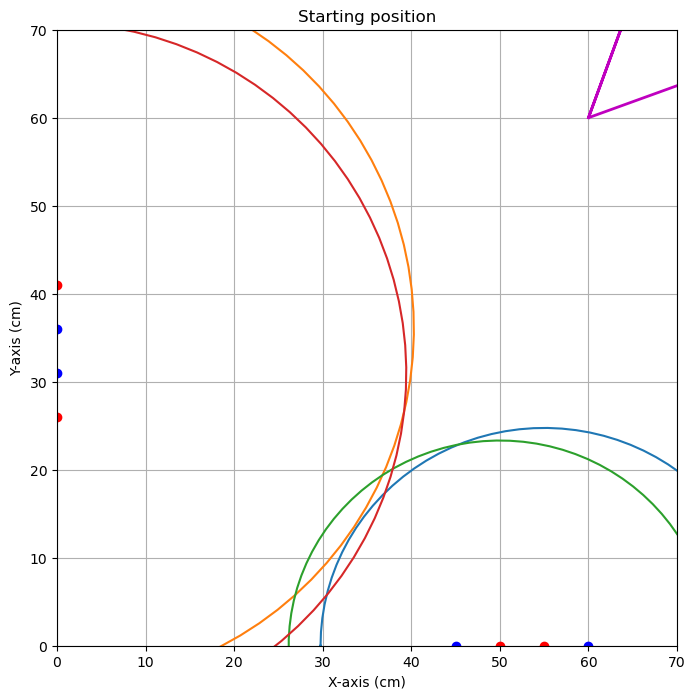


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.919


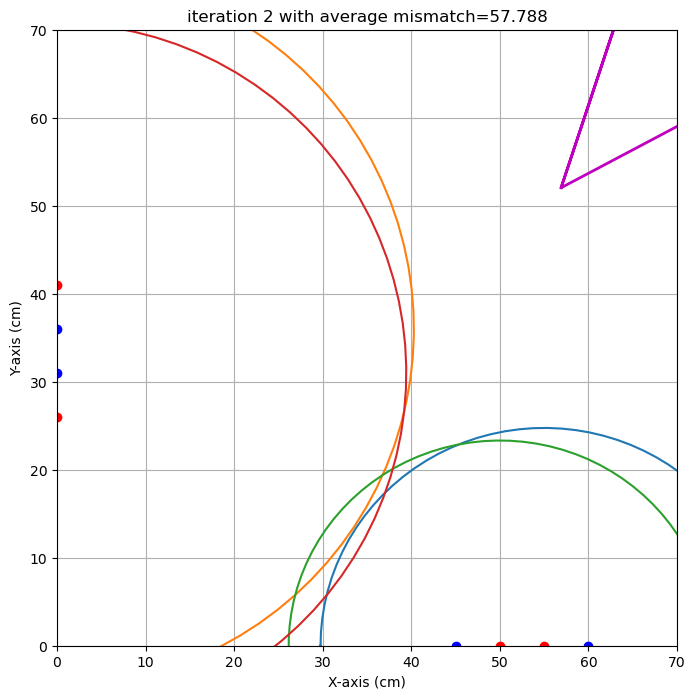

end iteration 2 with average mismatch=57.788


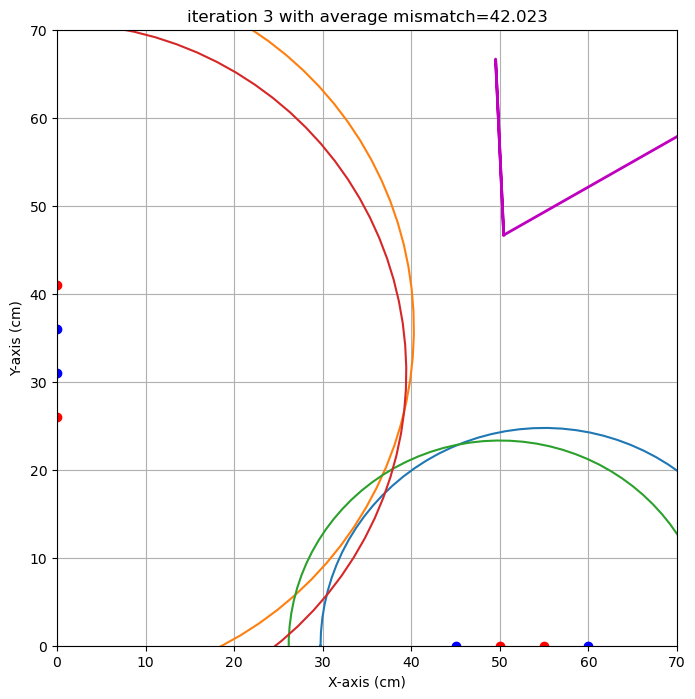

end iteration 3 with average mismatch=42.023


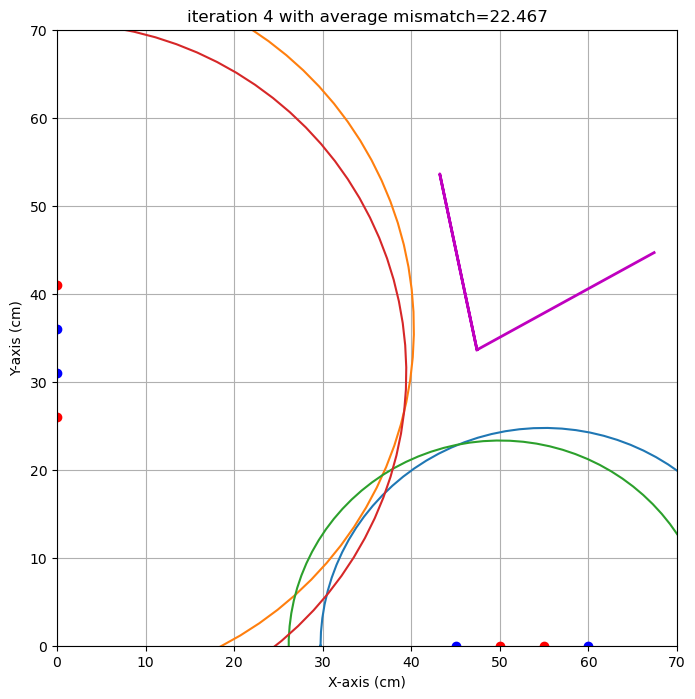

end iteration 4 with average mismatch=22.467


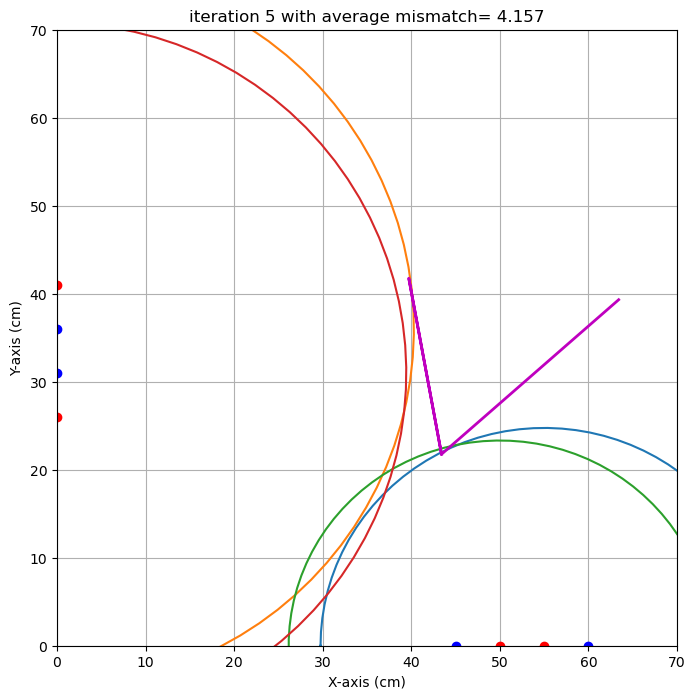

end iteration 5 with average mismatch= 4.157


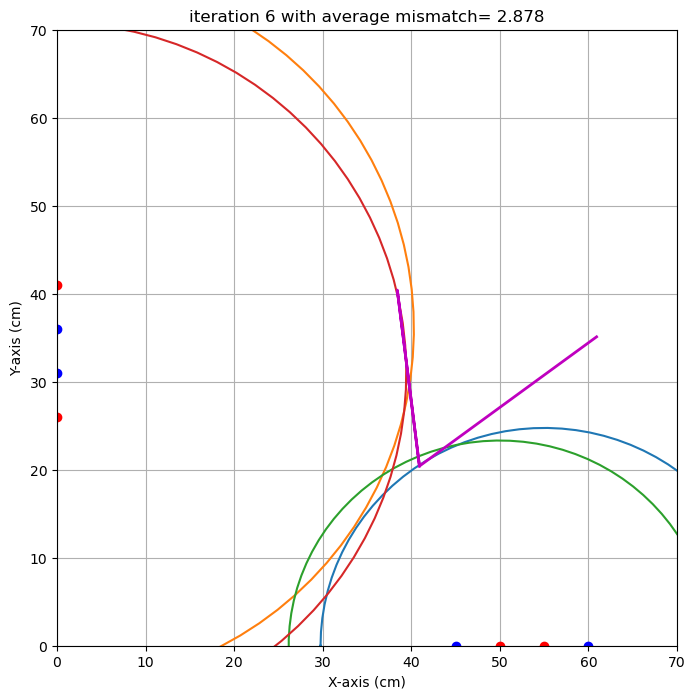

end iteration 6 with average mismatch= 2.878


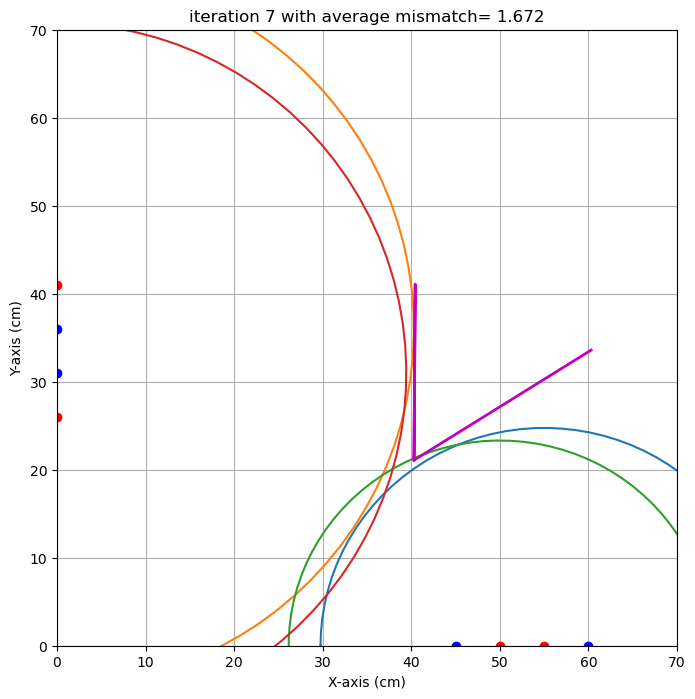

end iteration 7 with average mismatch= 1.672


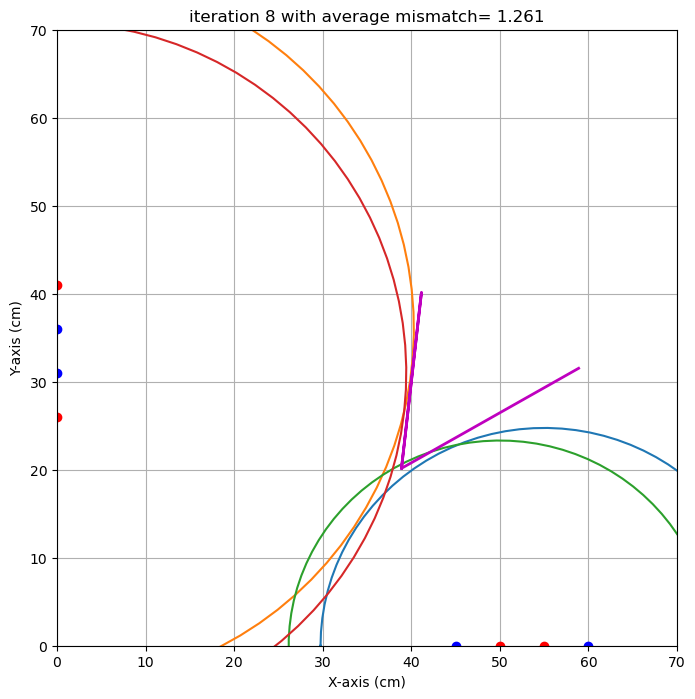

end iteration 8 with average mismatch= 1.261


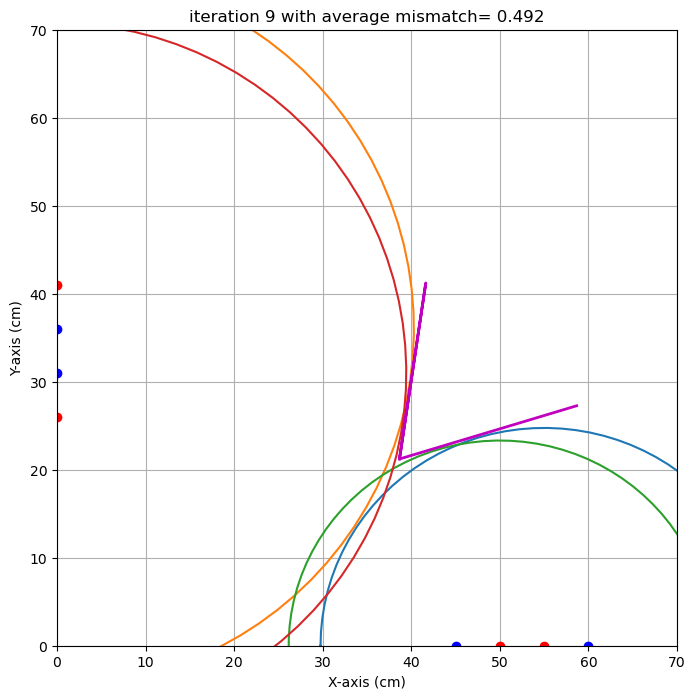

end iteration 9 with average mismatch= 0.492


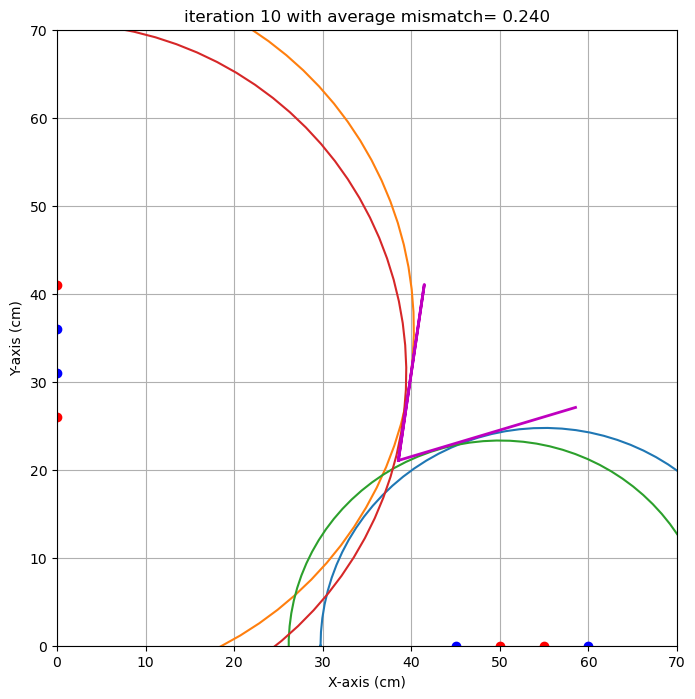

end iteration 10 with average mismatch= 0.240
end iteration 11 with average mismatch= 0.234
end iteration 12 with average mismatch= 0.232
end iteration 13 with average mismatch= 0.232
end iteration 14 with average mismatch= 0.231
end iteration 15 with average mismatch= 0.231
end iteration 16 with average mismatch= 0.231
end iteration 17 with average mismatch= 0.231
end iteration 18 with average mismatch= 0.231
end iteration 19 with average mismatch= 0.231
end iteration 20 with average mismatch= 0.231
end iteration 21 with average mismatch= 0.231
end iteration 22 with average mismatch= 0.231
end iteration 23 with average mismatch= 0.231
end iteration 24 with average mismatch= 0.231
end iteration 25 with average mismatch= 0.231
end iteration 26 with average mismatch= 0.231
end iteration 27 with average mismatch= 0.231
end iteration 28 with average mismatch= 0.231
end iteration 29 with average mismatch= 0.231
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

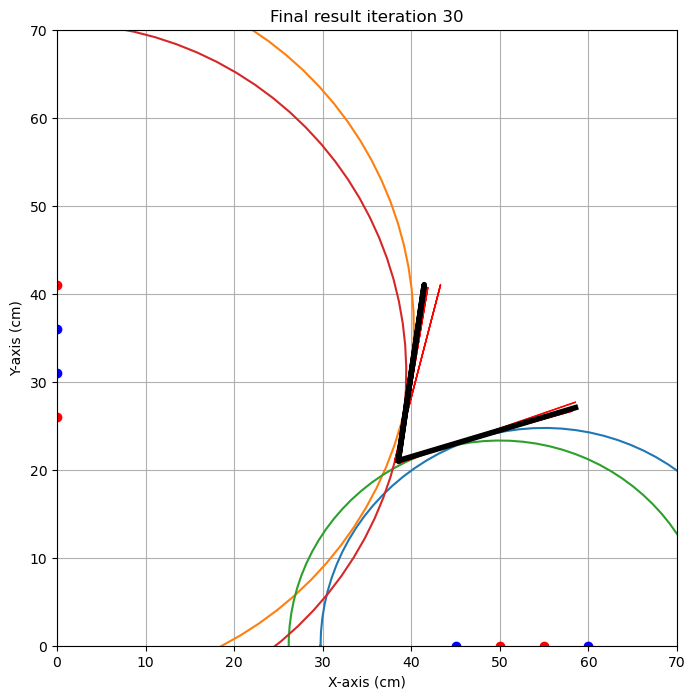

{'alpha': np.float64(16.755086354668368), 'alpha_eps': np.float64(2.411961042518193), 'beta': np.float64(8.327348068475592), 'beta_eps': np.float64(6.158982318998753), 'x0': np.float64(38.53061646642068), 'x0_eps': np.float64(0.40009002852960407), 'y0': np.float64(21.035261462032352), 'y0_eps': np.float64(0.32064790560052714)}


In [11]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [18]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Luuc 
x0 target is : 38.0. Gevonden waarde: 38.9 cm met een standaardafwijking van 3.2 cm 
y0 target is : 21.5. Gevonden waarde: 38.7 cm met een standaardafwijking van 1.4 cm 
alpha target is : 15.0. Gevonden waarde: 22.5 graden met een standaardafwijking van 14.5 graad 
beta target is : 10.0. Gevonden waarde: 9.6 graden met een standaardafwijking van 9.7 graad 

Max 
x0 target is : 38.0. Gevonden waarde: 43.1 cm met een standaardafwijking van 1.0 cm 
y0 target is : 21.5. Gevonden waarde: 41.9 cm met een standaardafwijking van 0.7 cm 
alpha target is : 15.0. Gevonden waarde: 10.1 graden met een standaardafwijking van 4.6 graad 
beta target is : 10.0. Gevonden waarde: 1.2 graden met een standaardafwijking van 4.3 graad 

Robert 
x0 target is : 38.0. Gevonden waarde: 38.5 cm met een standaardafwijking van 0.4 cm 
y0 target is : 21.5. Gevonden waarde: 21.0 cm met een standaardafwijking van 0.3 cm 
alpha target is : 15.0. Gevonden waarde: 16.8 graden met een standaardafwijking van 2.4 graa

## Opdracht 8: Iteratie1+. 16:00
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](tudelftLogo.png)


In [32]:
meting = 70.8
afstand_tussen_sensoren = 10

m = np.sqrt((meting/2)**2 - (afstand_tussen_sensoren/2)**2)
print(m)

35.045113782095214


## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  60   0  50.5
1   0  41   0  31  81.2
2  55   0  45   0  47.7
3   0  26   0  36  79.5


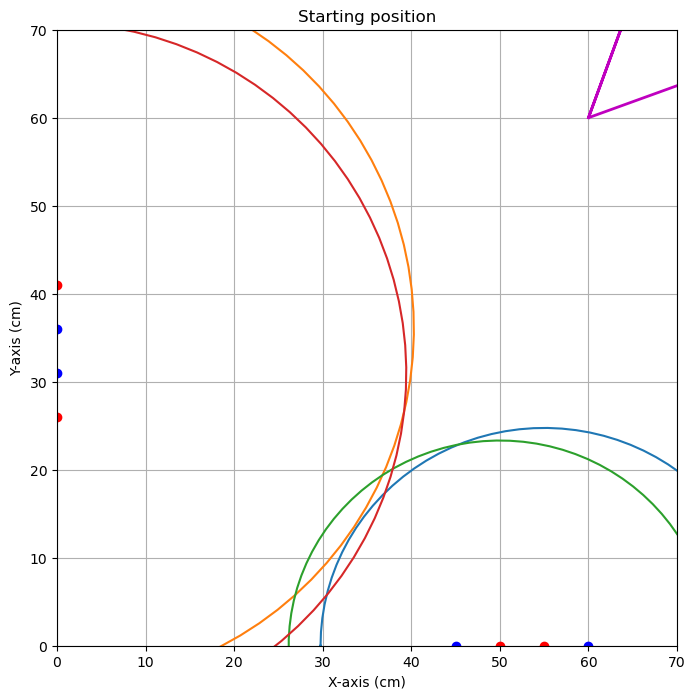


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.919


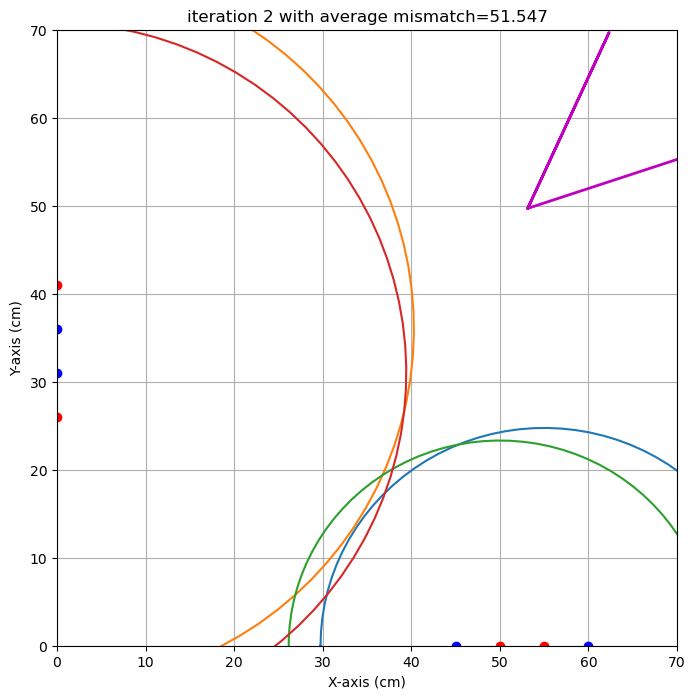

end iteration 2 with average mismatch=51.547


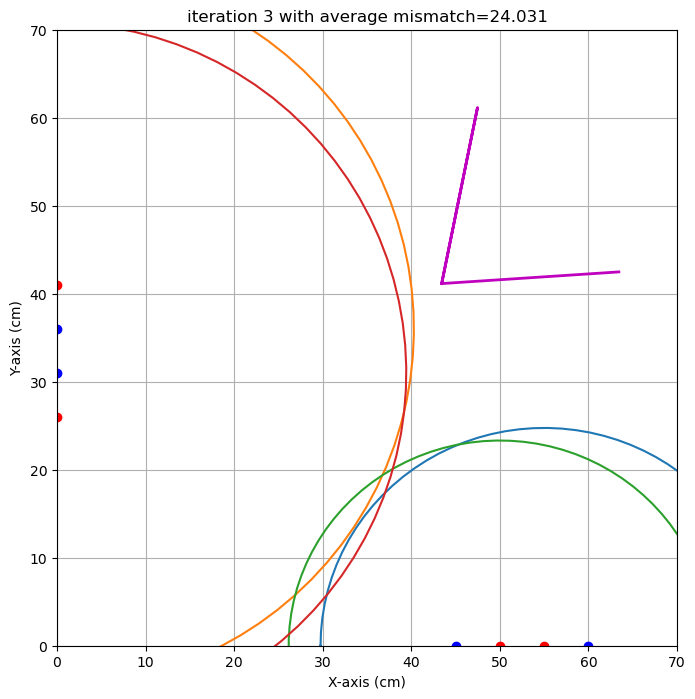

end iteration 3 with average mismatch=24.031


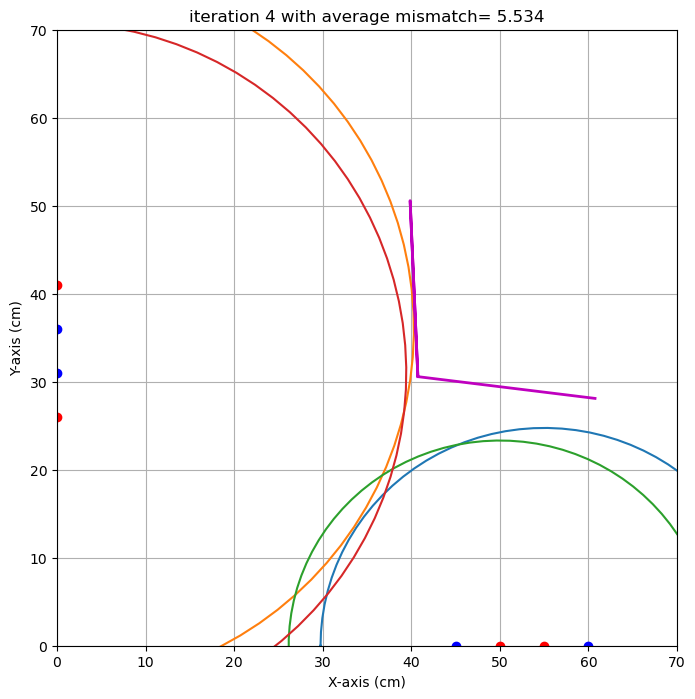

end iteration 4 with average mismatch= 5.534


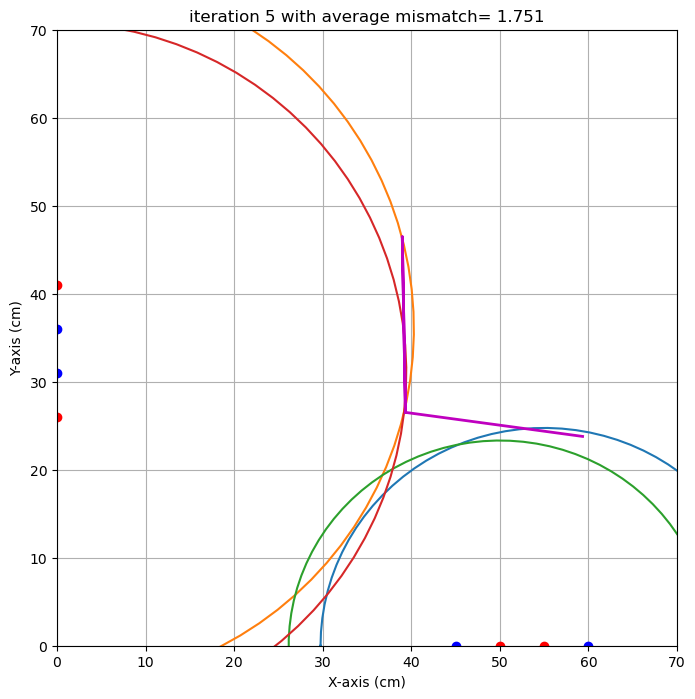

end iteration 5 with average mismatch= 1.751


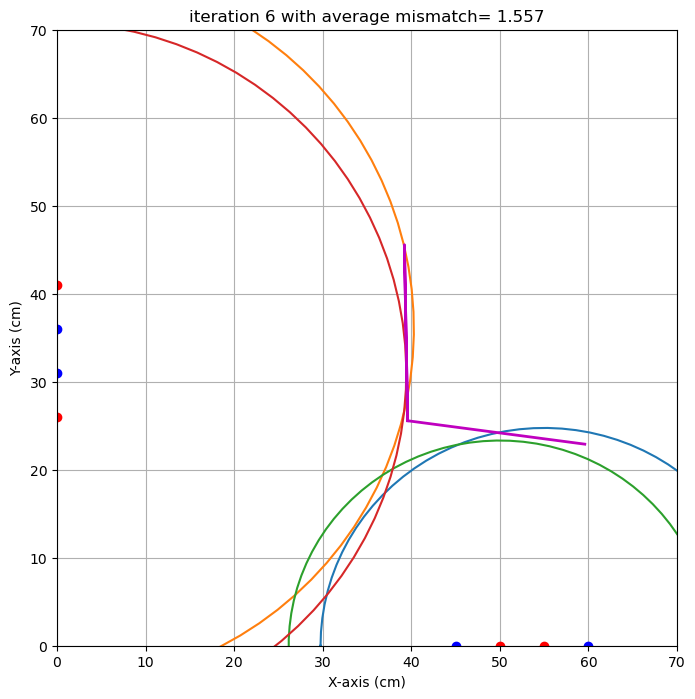

end iteration 6 with average mismatch= 1.557
end iteration 7 with average mismatch= 1.513
end iteration 8 with average mismatch= 1.505
end iteration 9 with average mismatch= 1.505
end iteration 10 with average mismatch= 1.505
end iteration 11 with average mismatch= 1.505
end iteration 12 with average mismatch= 1.505


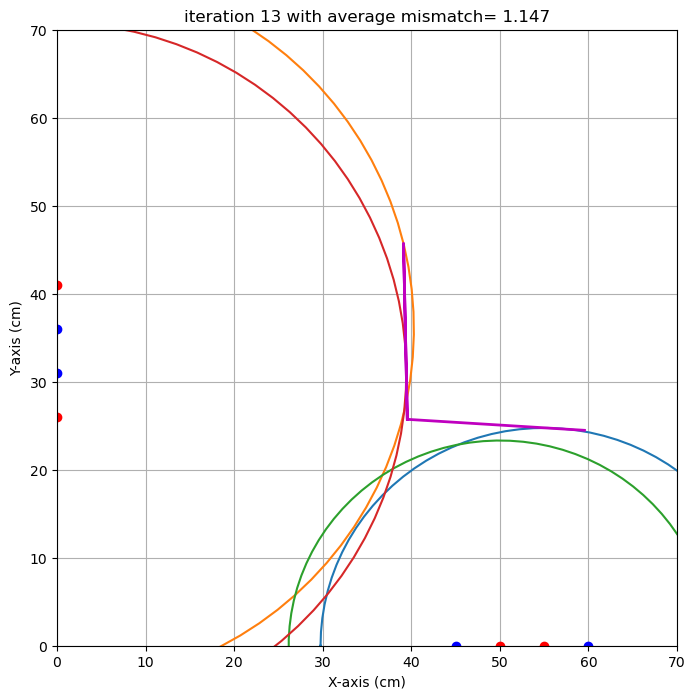

end iteration 13 with average mismatch= 1.147
end iteration 14 with average mismatch= 1.147
end iteration 15 with average mismatch= 1.147
end iteration 16 with average mismatch= 1.147
end iteration 17 with average mismatch= 1.147
end iteration 18 with average mismatch= 1.147
end iteration 19 with average mismatch= 1.147
end iteration 20 with average mismatch= 1.147
end iteration 21 with average mismatch= 1.147
end iteration 22 with average mismatch= 1.147
end iteration 23 with average mismatch= 1.147
end iteration 24 with average mismatch= 1.147


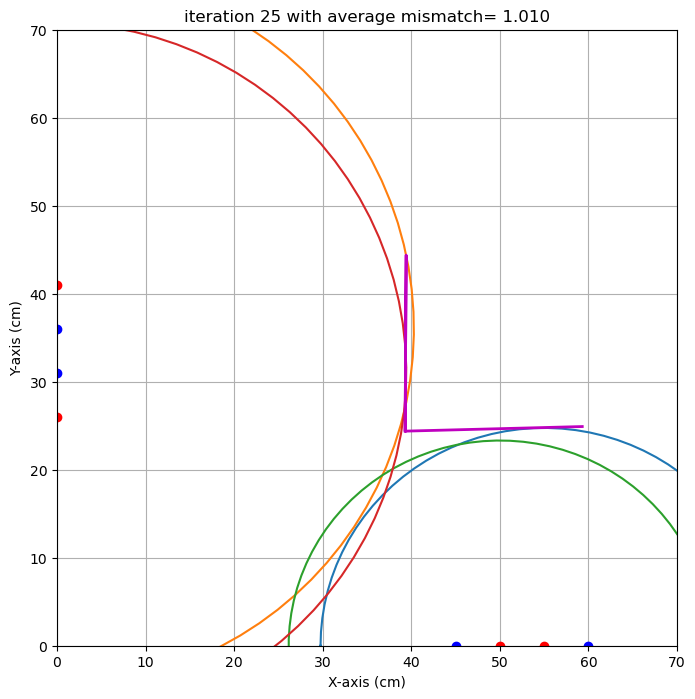

end iteration 25 with average mismatch= 1.010
end iteration 26 with average mismatch= 1.010


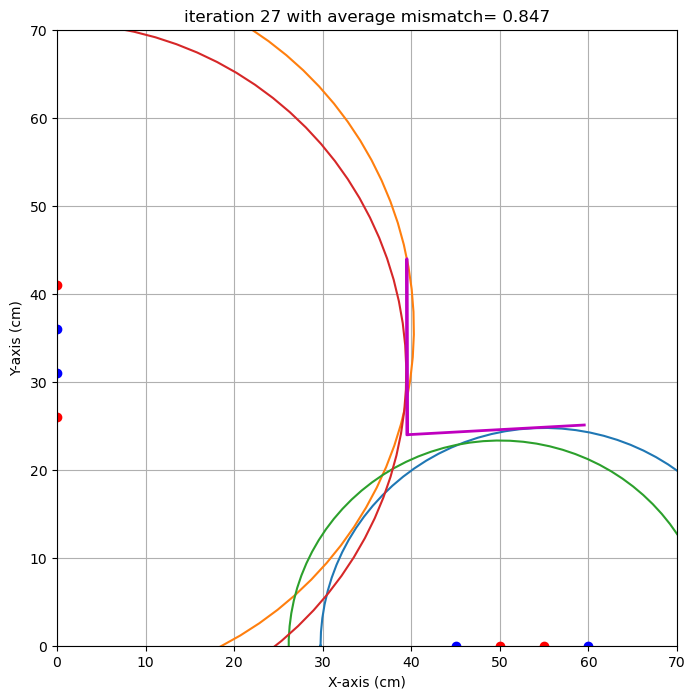

end iteration 27 with average mismatch= 0.847
end iteration 28 with average mismatch= 0.844
end iteration 29 with average mismatch= 0.844
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....


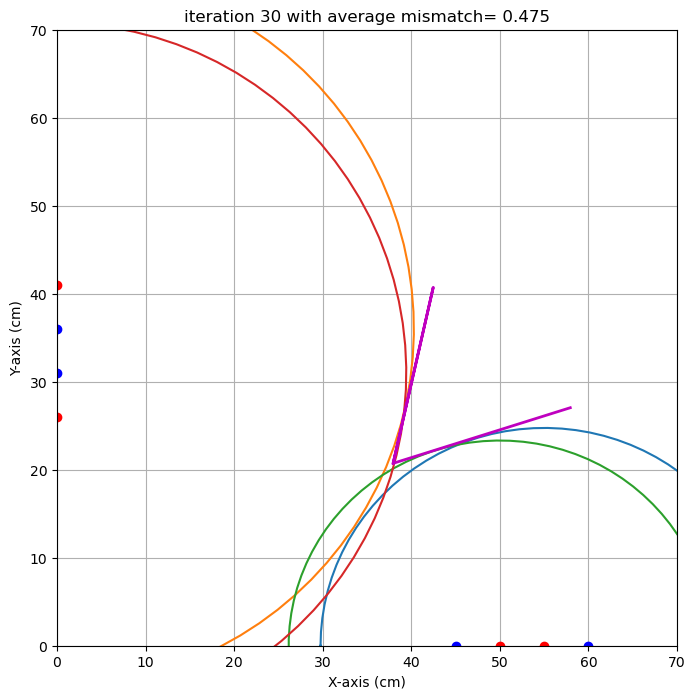

end iteration 30 with average mismatch= 0.475
###############################################################################
end of iteration  30
Best alpha=  17.53 with uncertainty=   6.74
Best beta =  12.76 with uncertainty=   7.68
Best x0   =  37.95 with uncertainty=   1.30
Best y0   =  20.73 with uncertainty=   1.04
###############################################################################


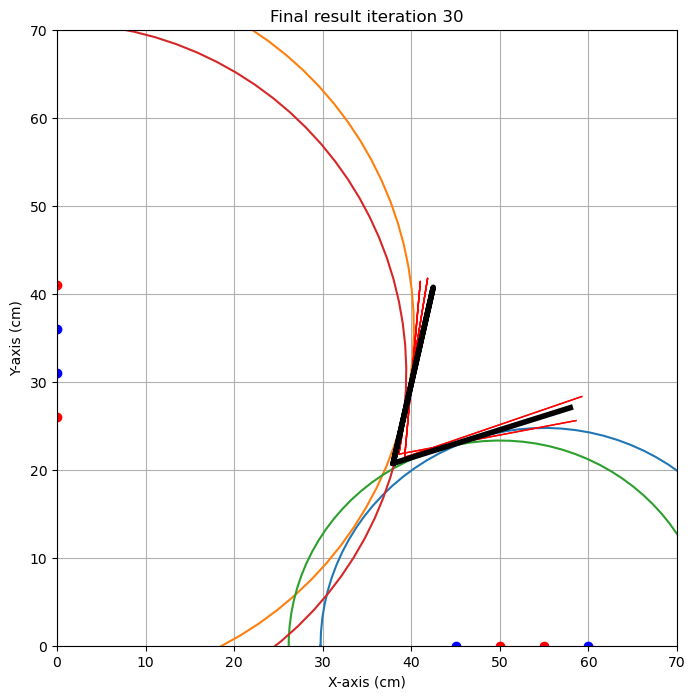

{'alpha': np.float64(17.529685603327554), 'alpha_eps': np.float64(6.737018022957027), 'beta': np.float64(12.760574245563921), 'beta_eps': np.float64(7.682176458511173), 'x0': np.float64(37.94713372420015), 'x0_eps': np.float64(1.2983049278928647), 'y0': np.float64(20.728289915292052), 'y0_eps': np.float64(1.0423386142919178)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  60   0  73.0
1   0  43   0  53  73.7
2  55   0  45   0  71.5
3   0  48   0  38  72.0


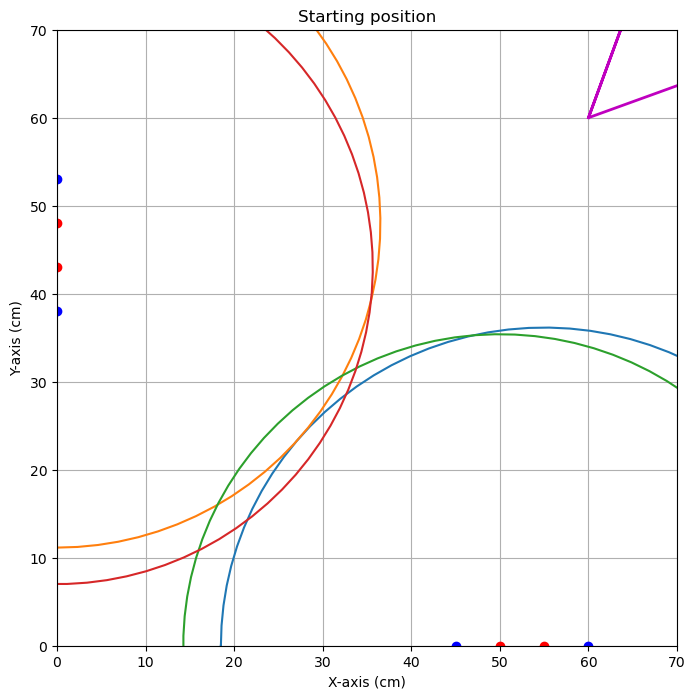


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=56.571


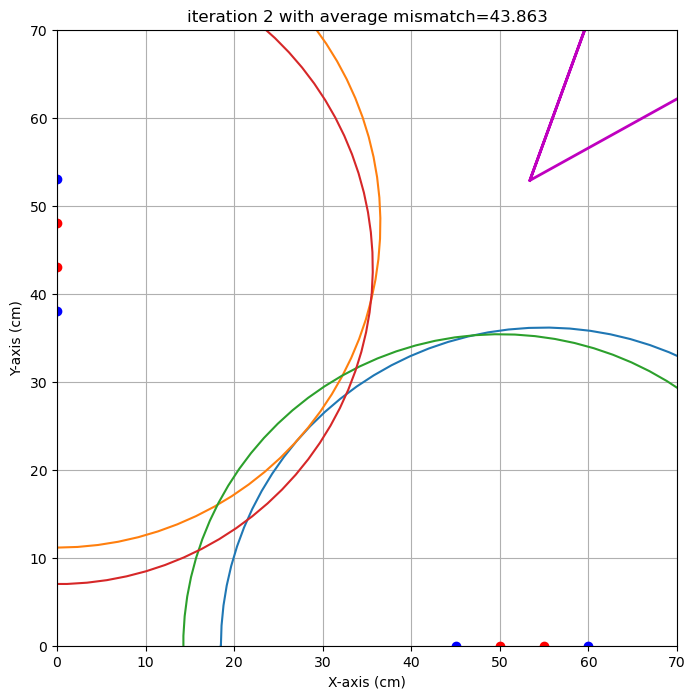

end iteration 2 with average mismatch=43.863


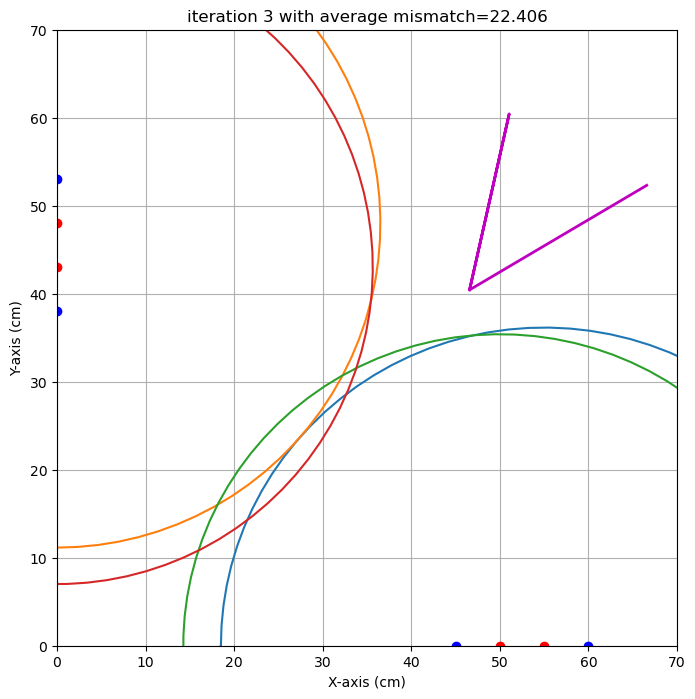

end iteration 3 with average mismatch=22.406


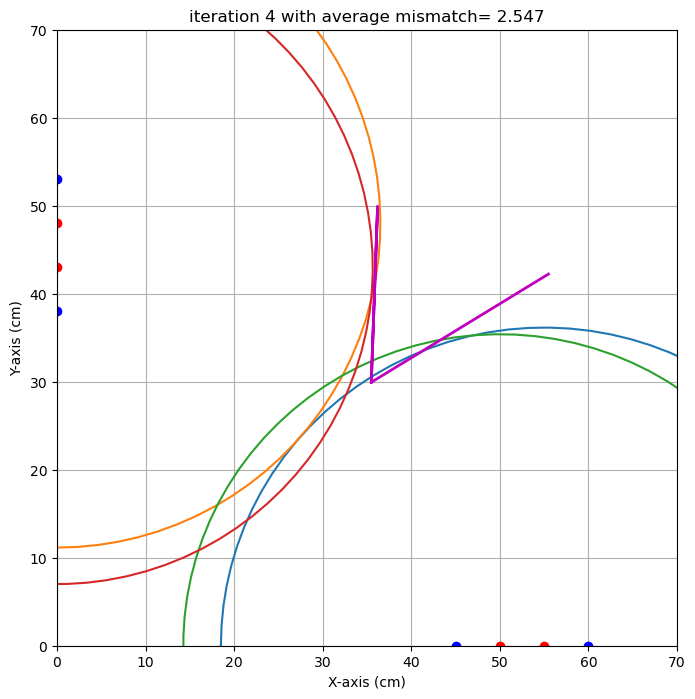

end iteration 4 with average mismatch= 2.547


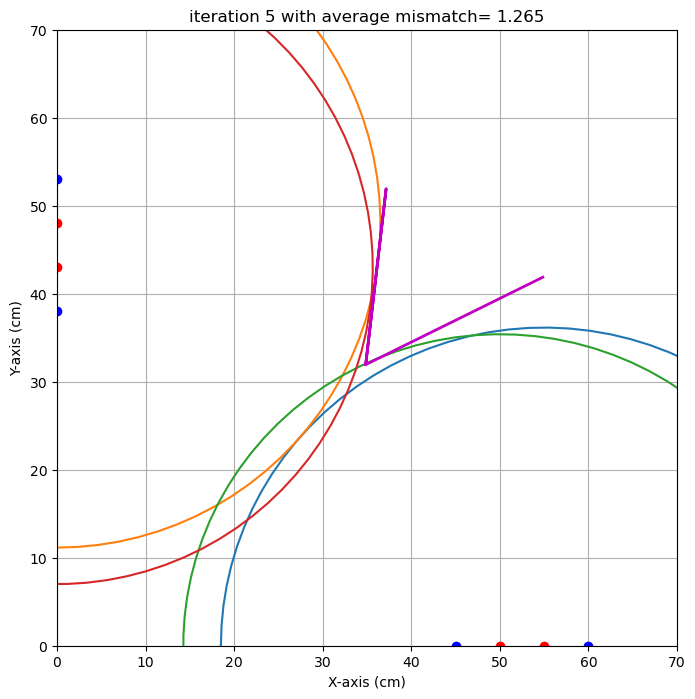

end iteration 5 with average mismatch= 1.265


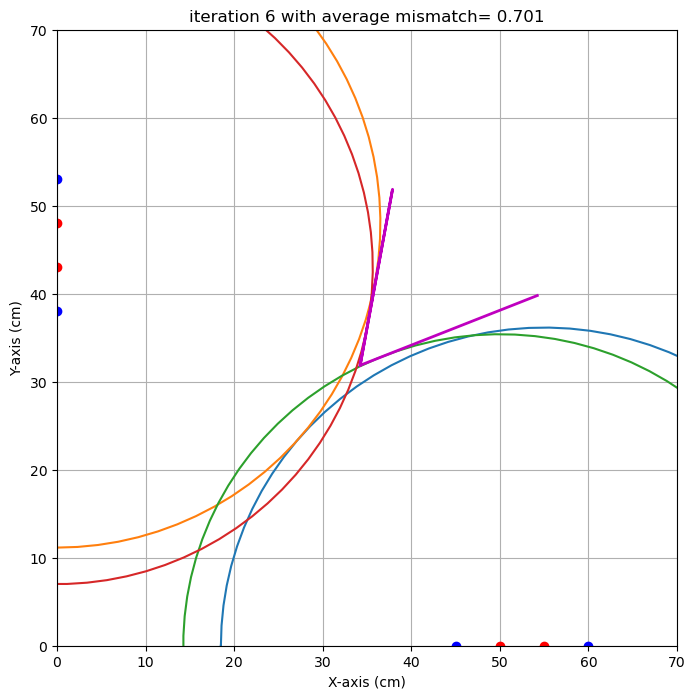

end iteration 6 with average mismatch= 0.701
end iteration 7 with average mismatch= 0.691
end iteration 8 with average mismatch= 0.691
end iteration 9 with average mismatch= 0.691
end iteration 10 with average mismatch= 0.691
end iteration 11 with average mismatch= 0.691
end iteration 12 with average mismatch= 0.691
end iteration 13 with average mismatch= 0.691
end iteration 14 with average mismatch= 0.691
end iteration 15 with average mismatch= 0.691
end iteration 16 with average mismatch= 0.691
end iteration 17 with average mismatch= 0.691
end iteration 18 with average mismatch= 0.691
end iteration 19 with average mismatch= 0.691
end iteration 20 with average mismatch= 0.672


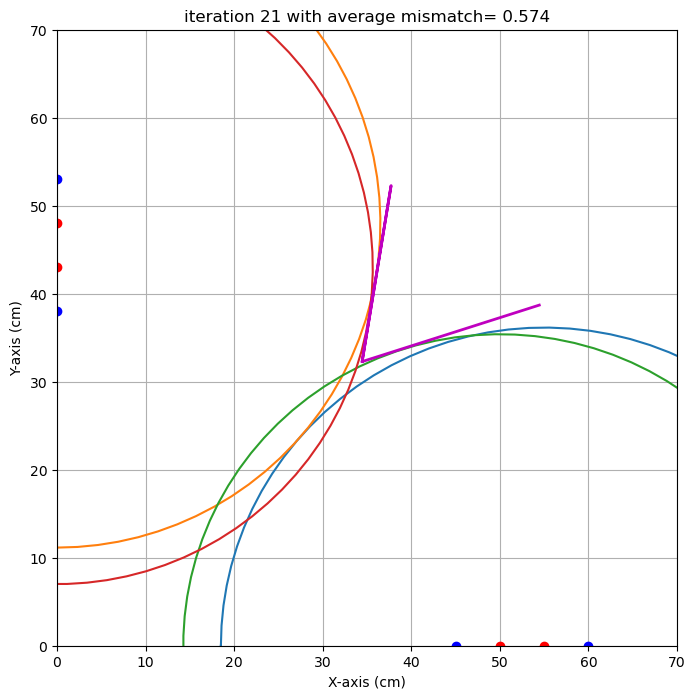

end iteration 21 with average mismatch= 0.574
end iteration 22 with average mismatch= 0.535
end iteration 23 with average mismatch= 0.526
end iteration 24 with average mismatch= 0.525
end iteration 25 with average mismatch= 0.525


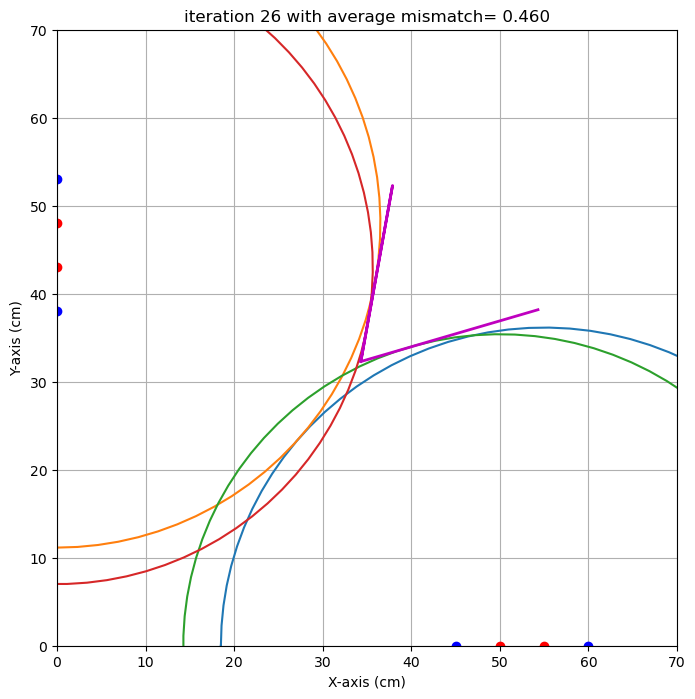

end iteration 26 with average mismatch= 0.460
end iteration 27 with average mismatch= 0.428
end iteration 28 with average mismatch= 0.390


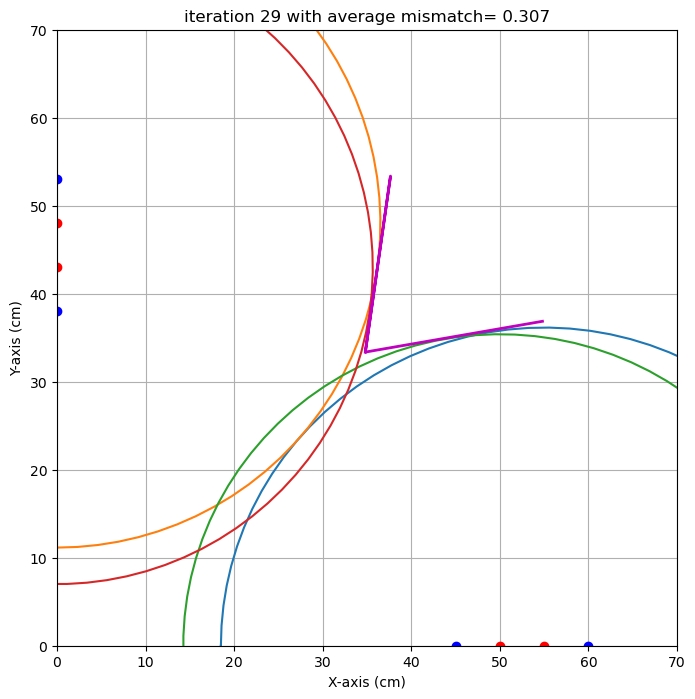

end iteration 29 with average mismatch= 0.307
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.281
###############################################################################
end of iteration  30
Best alpha=   9.91 with uncertainty=   5.78
Best beta =   8.09 with uncertainty=   6.63
Best x0   =  34.79 with uncertainty=   0.73
Best y0   =  33.34 with uncertainty=   1.42
###############################################################################


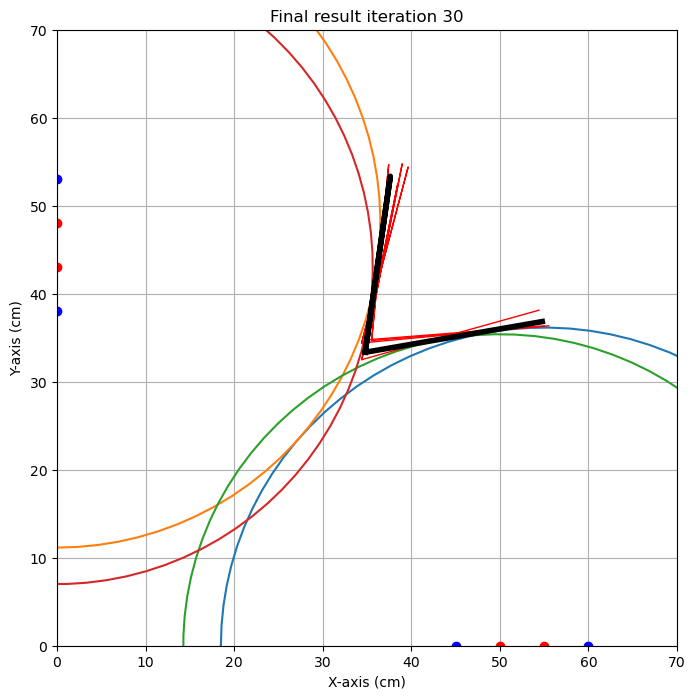

{'alpha': np.float64(9.90669887599926), 'alpha_eps': np.float64(5.777674045395804), 'beta': np.float64(8.087423971969468), 'beta_eps': np.float64(6.6303791449636105), 'x0': np.float64(34.7870101118849), 'x0_eps': np.float64(0.7261077755383596), 'y0': np.float64(33.34362502199119), 'y0_eps': np.float64(1.4218033255342135)}
locatie 1 
x0 target is : 38.0. Gevonden waarde: 37.9 cm met een standaardafwijking van 1.3 cm 
y0 target is : 21.5. Gevonden waarde: 20.7 cm met een standaardafwijking van 1.0 cm 
alpha target is : 15.0. Gevonden waarde: 17.5 graden met een standaardafwijking van 6.7 graad 
beta target is : 10.0. Gevonden waarde: 12.8 graden met een standaardafwijking van 7.7 graad 

locatie 2 
x0 target is : 34.0. Gevonden waarde: 34.8 cm met een standaardafwijking van 0.7 cm 
y0 target is : 33.0. Gevonden waarde: 33.3 cm met een standaardafwijking van 1.4 cm 
alpha target is : 13.0. Gevonden waarde: 9.9 graden met een standaardafwijking van 5.8 graad 
beta target is : 12.0. Gevonde

In [22]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':38,#zelf aanvullen,
                    'y0':21.5,  #zelf aanvullen,
                    'alpha' : 15, #zelf aanvullen,
                    'beta' : 10},  #zelf aanvullen
           'locatie 2':{'x0':34,#zelf aanvullen,
                    'y0':33,  #zelf aanvullen,
                    'alpha' : 13, #zelf aanvullen,
                    'beta' : 12}  #zelf aanvullen
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
        # [30,0,40,0, ongeldig]  
    [50,0,60,0,50.5],
    [0,41,0,31,81.2],
    [55,0,45,0,47.7],
    [0,26,0,36,79.5]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
            # [30,0,40,0, ongeldig]  
    [50,0,60,0,73],
    [0,43,0,53,73.7],
    [55,0,45,0,71.5],
    [0,48,0,38,72]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

Test 1, niet gehaald:

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  60   0  70.0
1   0  41   0  51  80.9
2  55   0  45   0  71.7
3   0  46   0  56  78.8


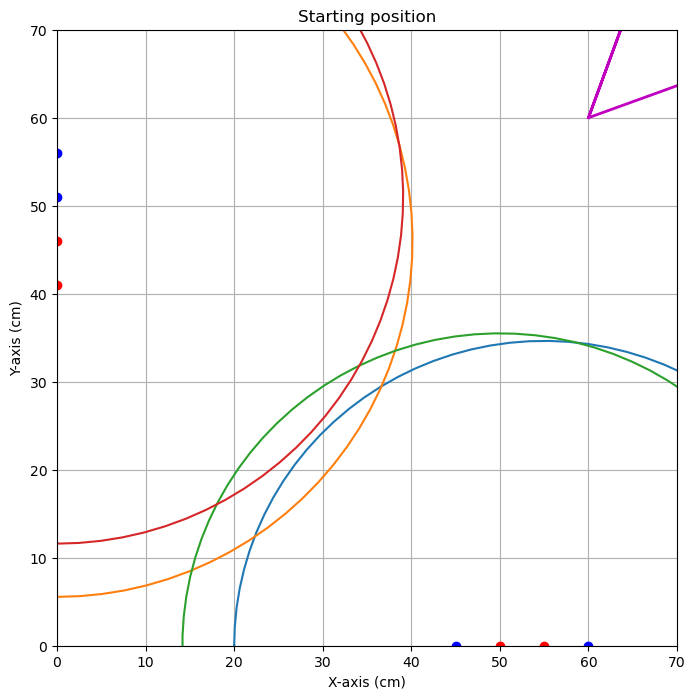


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=52.942


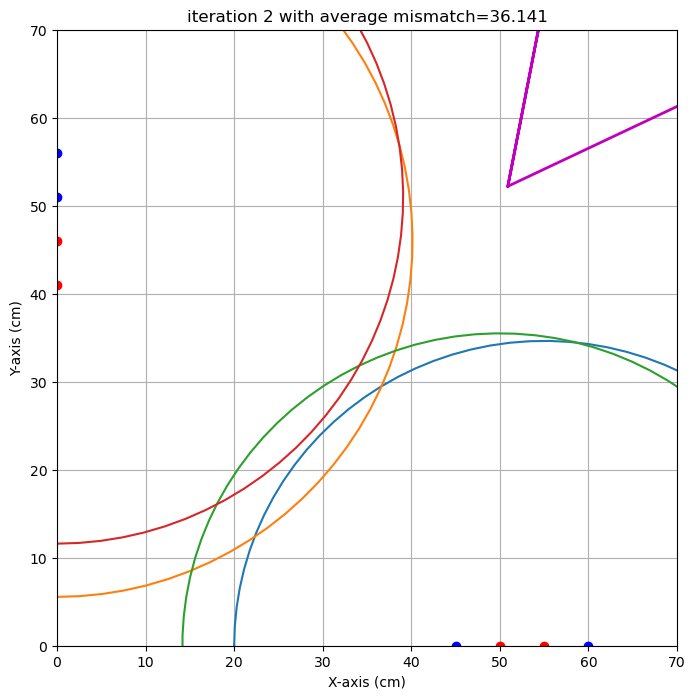

end iteration 2 with average mismatch=36.141


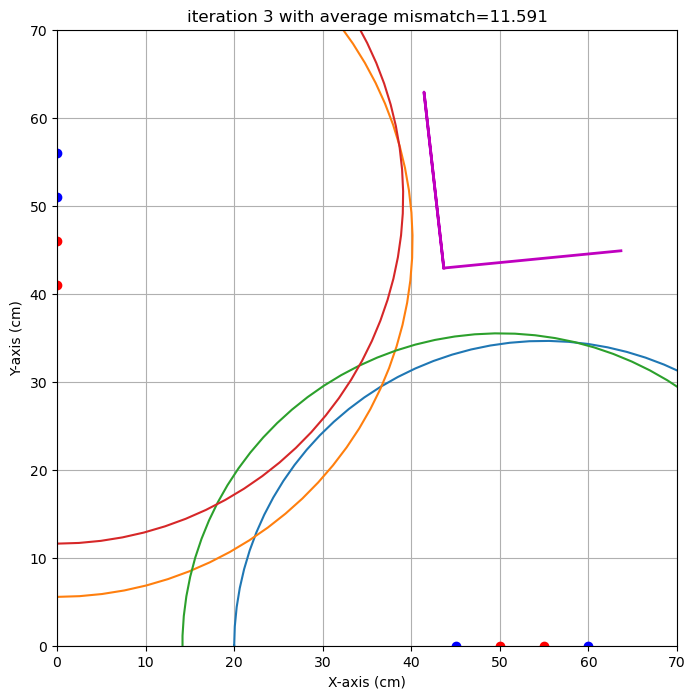

end iteration 3 with average mismatch=11.591


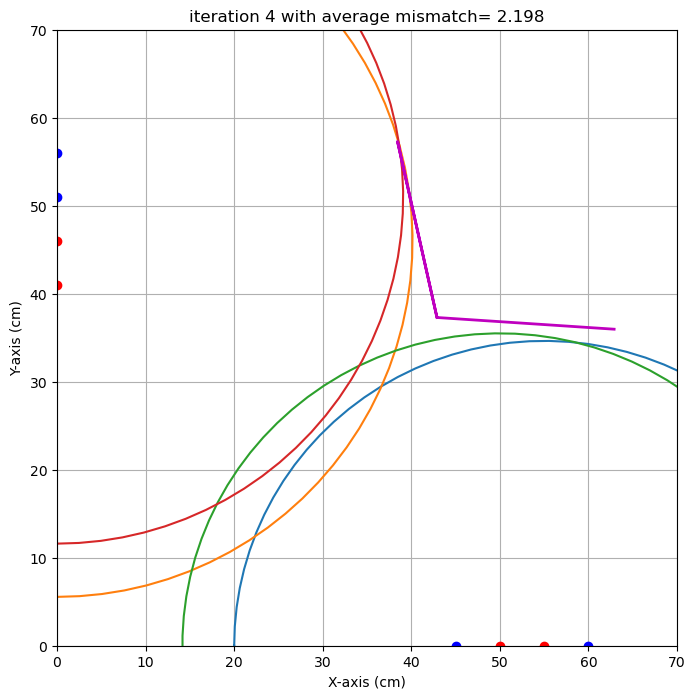

end iteration 4 with average mismatch= 2.198


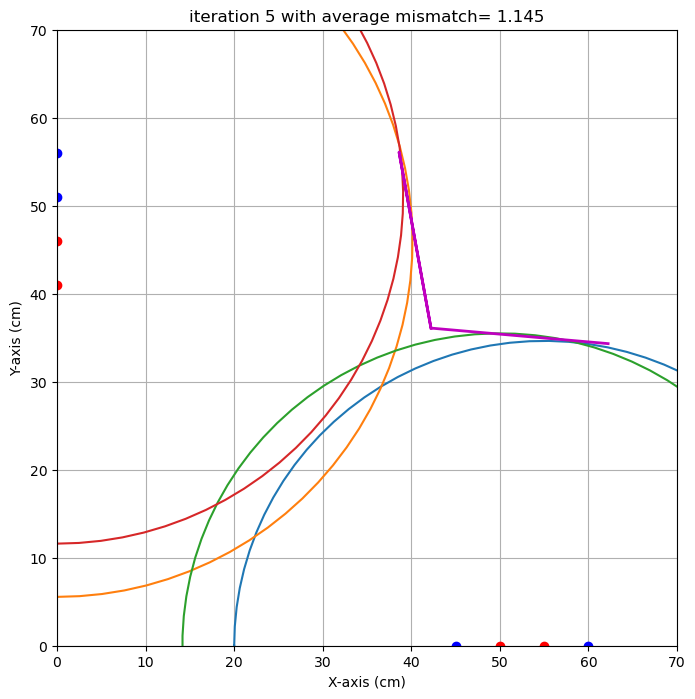

end iteration 5 with average mismatch= 1.145


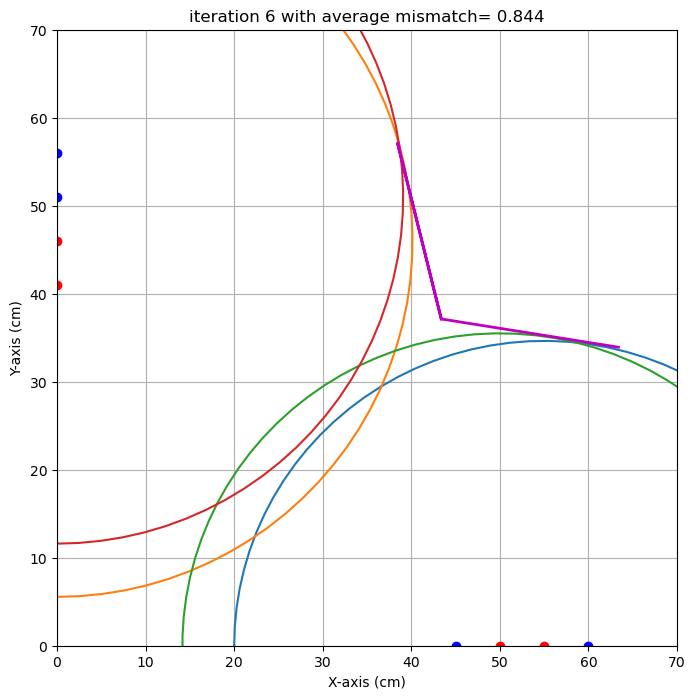

end iteration 6 with average mismatch= 0.844


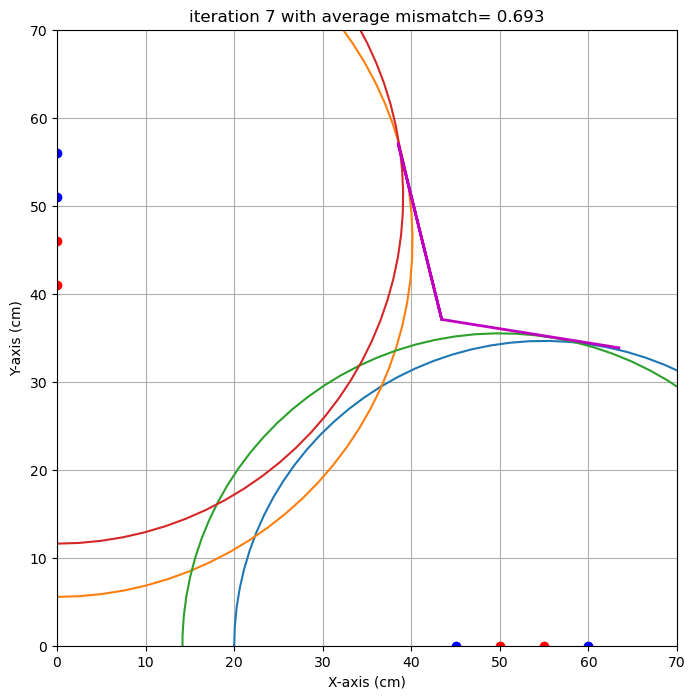

end iteration 7 with average mismatch= 0.693
end iteration 8 with average mismatch= 0.693
end iteration 9 with average mismatch= 0.693
end iteration 10 with average mismatch= 0.693
end iteration 11 with average mismatch= 0.660
end iteration 12 with average mismatch= 0.656
end iteration 13 with average mismatch= 0.654
end iteration 14 with average mismatch= 0.653
end iteration 15 with average mismatch= 0.653
end iteration 16 with average mismatch= 0.594


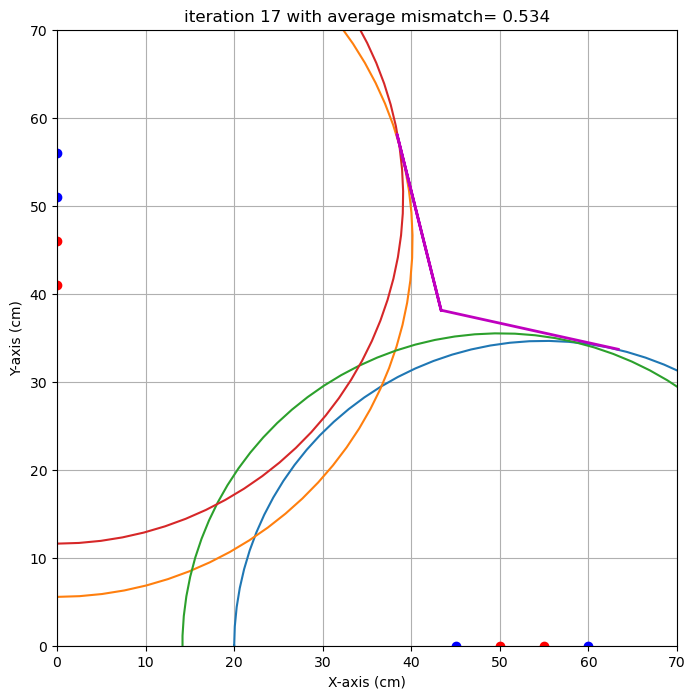

end iteration 17 with average mismatch= 0.534
end iteration 18 with average mismatch= 0.508
end iteration 19 with average mismatch= 0.505
end iteration 20 with average mismatch= 0.505
end iteration 21 with average mismatch= 0.505
end iteration 22 with average mismatch= 0.505
end iteration 23 with average mismatch= 0.505
end iteration 24 with average mismatch= 0.505
end iteration 25 with average mismatch= 0.505
end iteration 26 with average mismatch= 0.505
end iteration 27 with average mismatch= 0.505
end iteration 28 with average mismatch= 0.505
end iteration 29 with average mismatch= 0.505
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.505
###############################################################################
end of iteration  30
Best alpha= -12.52 with uncertainty=   8.46
Best beta = -14.00 with uncertainty=  10.30
Best x0   =  43.35 with uncertainty=   3.52
Best y0   =  3

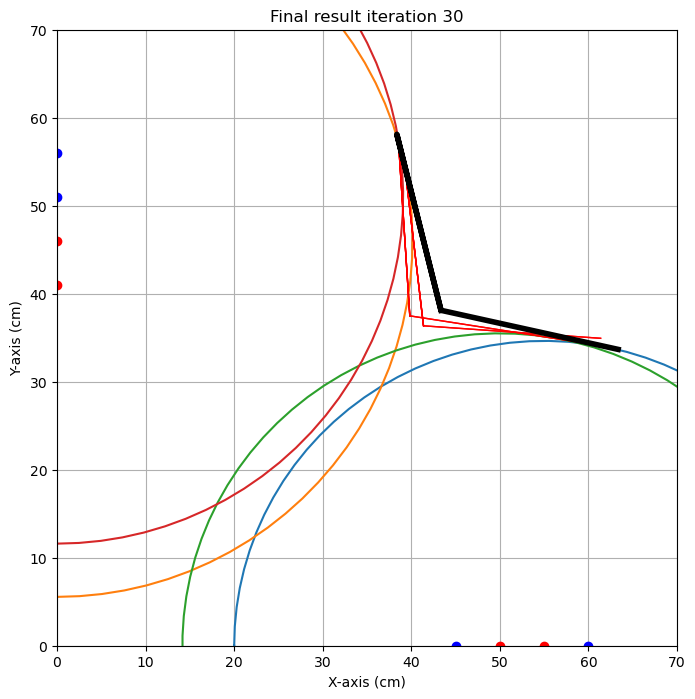

{'alpha': np.float64(-12.518740577887042), 'alpha_eps': np.float64(8.456391533410434), 'beta': np.float64(-14.002368394962174), 'beta_eps': np.float64(10.297757788847438), 'x0': np.float64(43.34984618199412), 'x0_eps': np.float64(3.519765767785124), 'y0': np.float64(38.11550576017495), 'y0_eps': np.float64(1.7611712462359108)}
test locatie 
x0 target is : 41.7. Gevonden waarde: 43.3 cm met een standaardafwijking van 3.5 cm 
y0 target is : 38.5. Gevonden waarde: 38.1 cm met een standaardafwijking van 1.8 cm 
alpha target is : -12.0. Gevonden waarde: -12.5 graden met een standaardafwijking van 8.5 graad 
beta target is : -10.0. Gevonden waarde: -14.0 graden met een standaardafwijking van 10.3 graad 



In [29]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':41.7,  # zelf aanvullen,
                    'y0':38.5,  # zelf aanvullen,
                    'alpha' : -12,  # zelf aanvullen,
                    'beta' : -10 # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # [30,0,40,0, ongeldig]  
    [50,0,60,0,70],
    [0,41,0,51,80.9],
    [55,0,45,0,71.7],
    [0,46,0,56,78.8]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

Test 2:

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  60   0  71.4
1   0  42   0  52  87.4
2  55   0  65   0  70.8
3  55   0  45   0  73.6
4   0  57   0  47  87.7
5   0  37   0  47  87.2


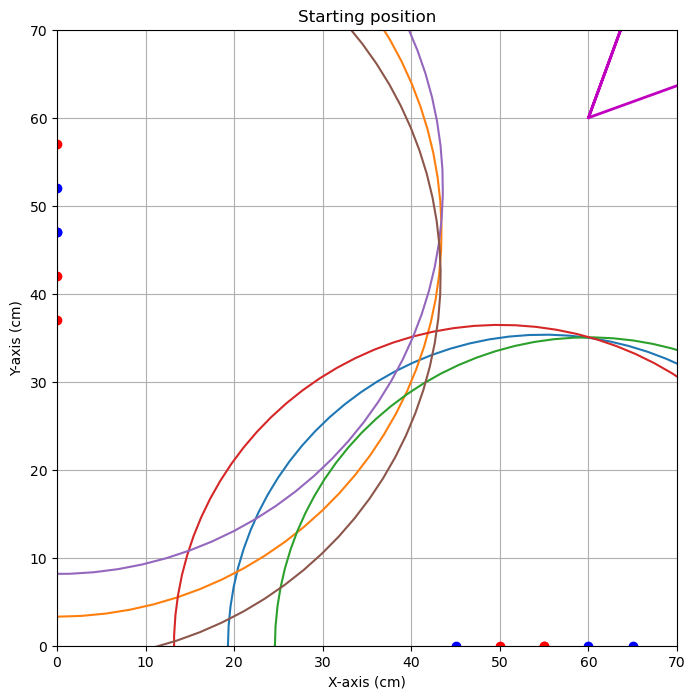


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=48.883


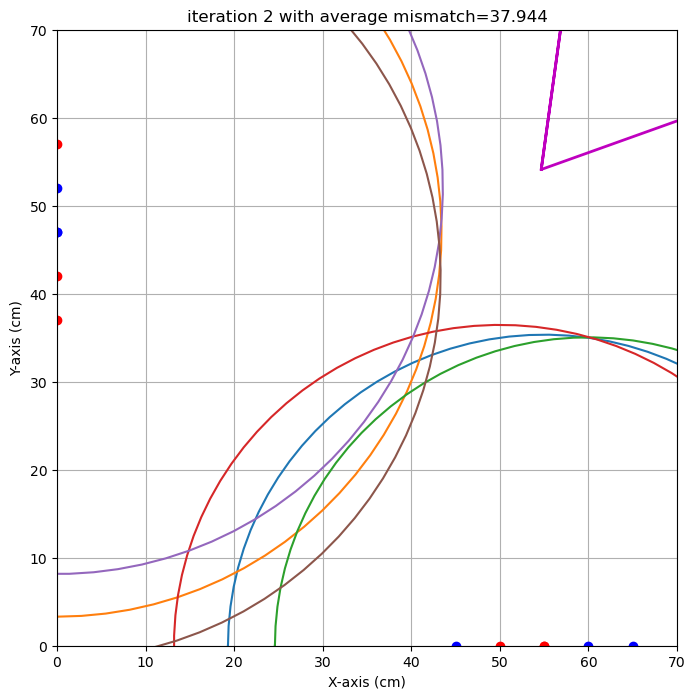

end iteration 2 with average mismatch=37.944


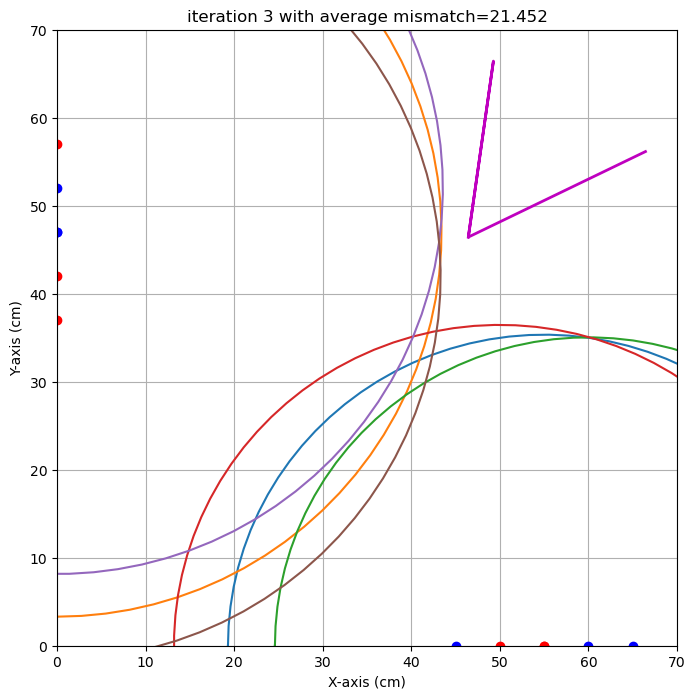

end iteration 3 with average mismatch=21.452


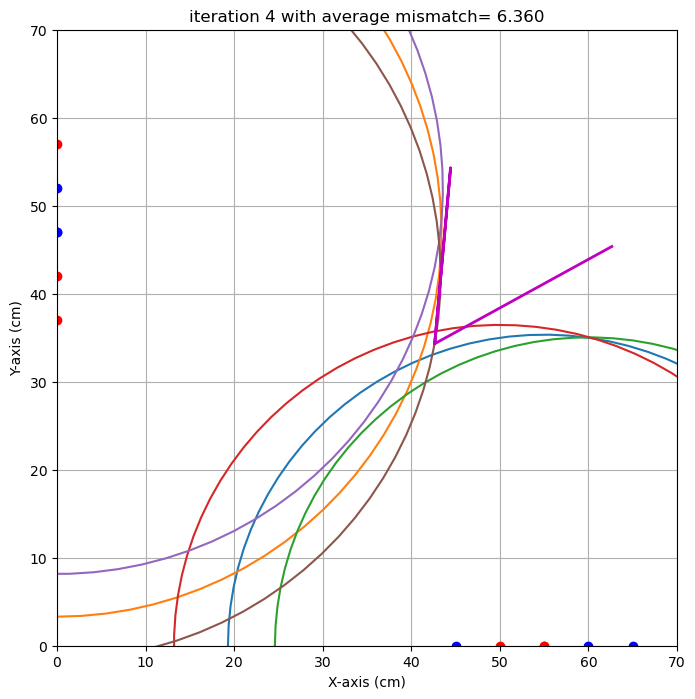

end iteration 4 with average mismatch= 6.360


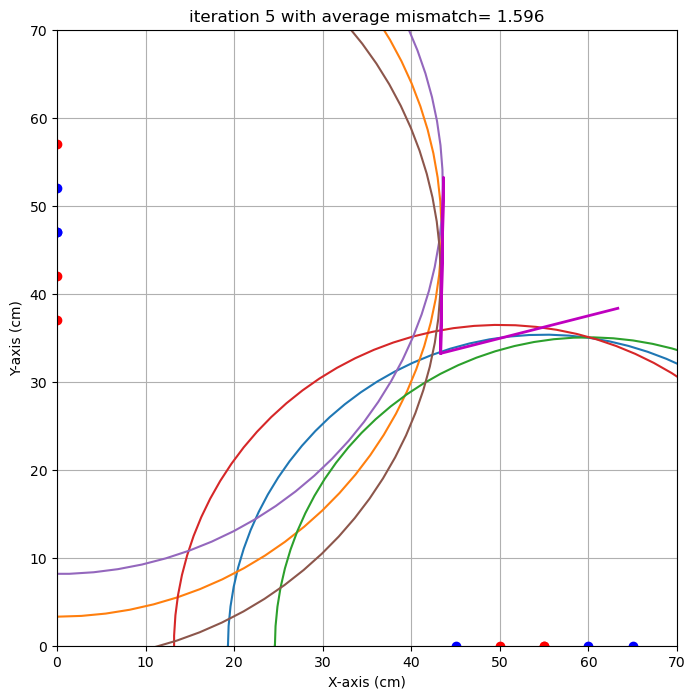

end iteration 5 with average mismatch= 1.596


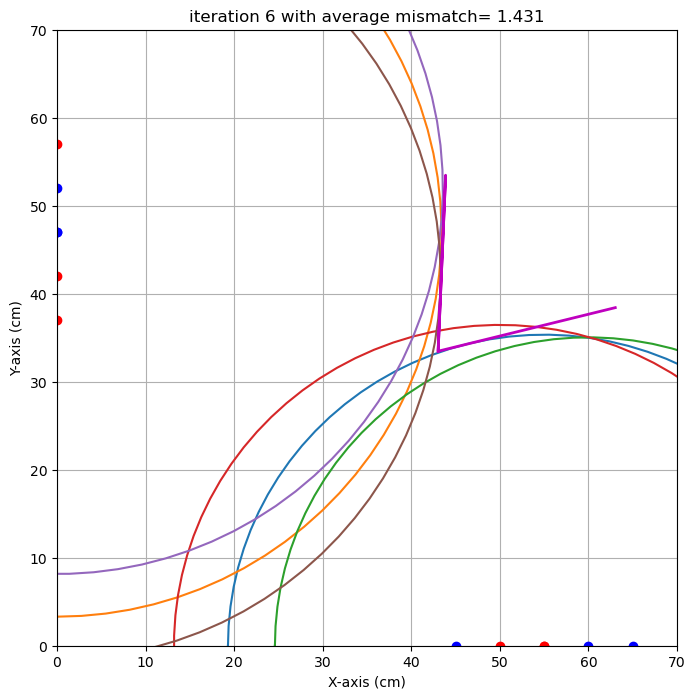

end iteration 6 with average mismatch= 1.431
end iteration 7 with average mismatch= 1.391
end iteration 8 with average mismatch= 1.391
end iteration 9 with average mismatch= 1.391
end iteration 10 with average mismatch= 1.391
end iteration 11 with average mismatch= 1.391
end iteration 12 with average mismatch= 1.391
end iteration 13 with average mismatch= 1.391
end iteration 14 with average mismatch= 1.391
end iteration 15 with average mismatch= 1.391
end iteration 16 with average mismatch= 1.391
end iteration 17 with average mismatch= 1.391
end iteration 18 with average mismatch= 1.369


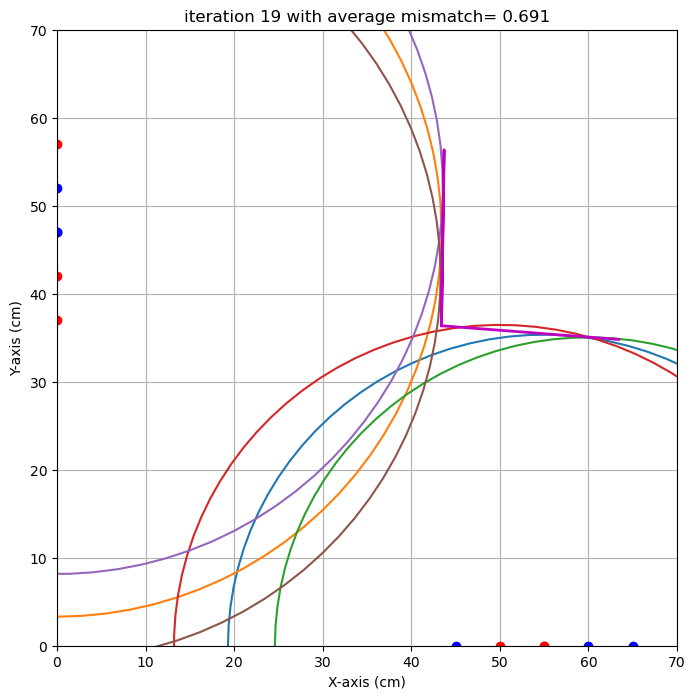

end iteration 19 with average mismatch= 0.691


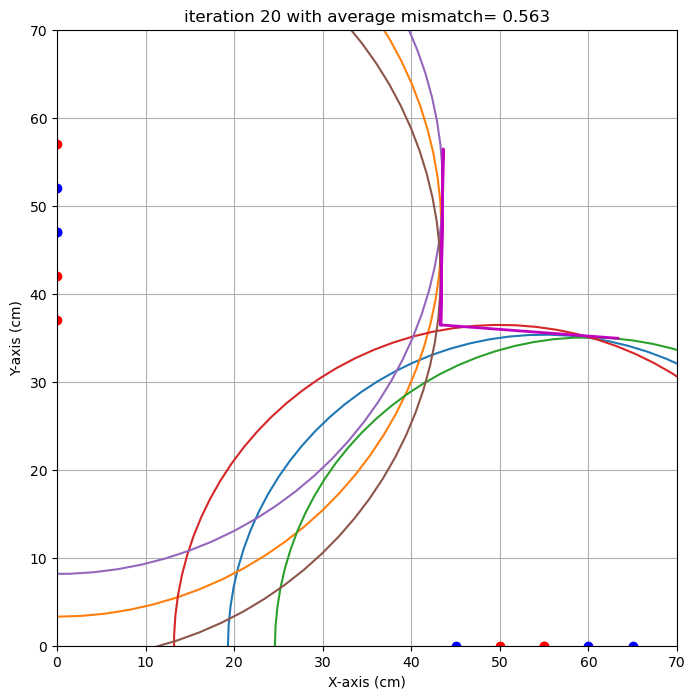

end iteration 20 with average mismatch= 0.563
end iteration 21 with average mismatch= 0.563
end iteration 22 with average mismatch= 0.563
end iteration 23 with average mismatch= 0.563
end iteration 24 with average mismatch= 0.563
end iteration 25 with average mismatch= 0.563
end iteration 26 with average mismatch= 0.563
end iteration 27 with average mismatch= 0.563
end iteration 28 with average mismatch= 0.563
end iteration 29 with average mismatch= 0.563
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.554
###############################################################################
end of iteration  30
Best alpha=  -9.03 with uncertainty=   4.11
Best beta =  -0.21 with uncertainty=   5.70
Best x0   =  43.48 with uncertainty=   1.10
Best y0   =  37.97 with uncertainty=   1.37
###############################################################################


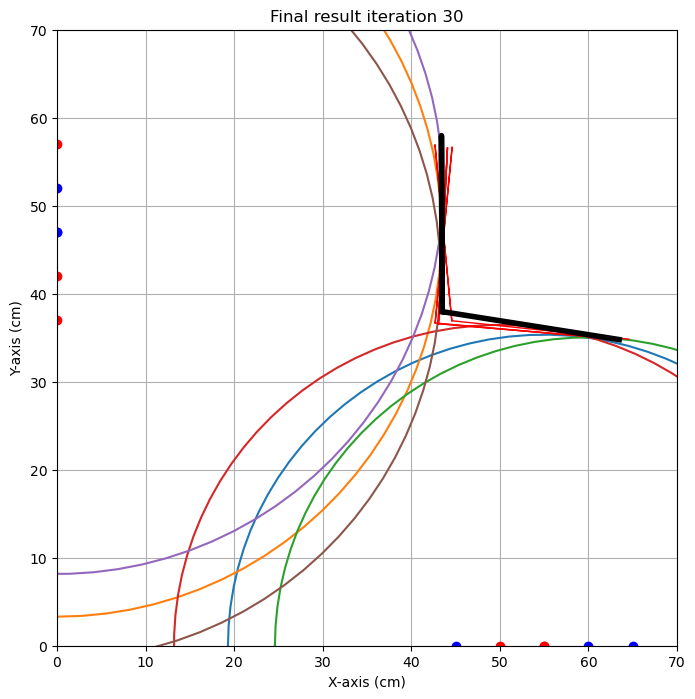

{'alpha': np.float64(-9.029062195140808), 'alpha_eps': np.float64(4.11003298840972), 'beta': np.float64(-0.2139332730175828), 'beta_eps': np.float64(5.702003410901519), 'x0': np.float64(43.476746288705385), 'x0_eps': np.float64(1.096778480695157), 'y0': np.float64(37.96625570686258), 'y0_eps': np.float64(1.3746267992586425)}
test locatie 
x0 target is : 43.7. Gevonden waarde: 43.5 cm met een standaardafwijking van 1.1 cm 
y0 target is : 37.2. Gevonden waarde: 38.0 cm met een standaardafwijking van 1.4 cm 
alpha target is : -9.0. Gevonden waarde: -9.0 graden met een standaardafwijking van 4.1 graad 
beta target is : 3.0. Gevonden waarde: -0.2 graden met een standaardafwijking van 5.7 graad 



In [34]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':43.7,  # zelf aanvullen,
                    'y0':37.2,  # zelf aanvullen,
                    'alpha' : -9,  # zelf aanvullen,
                    'beta' : 3 # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # [30,0,40,0, ongeldig]  
    [50,0,60,0,71.4],
    [0,42,0,52,87.4],
    [55,0,65,0,70.8],
    [55,0,45,0,73.6],
    [0,57,0,47,87.7],
    [0,37,0,47,87.2]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Iteratie 0 & 1:
![Alt](foto_3.jpeg "Iteratie 0 & 1")

Bij iteratie 1 hebben we tov iteratie 0 de alleen de eerste stap aangepast. In plaats van stap voor stap (eerst rond x=25, dan rond x=35, etc.) opzoek te gaan naar het papiertje, beginnen we nu bij x=35 en springen we daarna (als x=35 een ongeldige meting is) gelijk naar x=55. Door de grootte van het papiertje weet je zeker dat hij bij ofwel x=35 ofwel x=55 staat. Dit bespaart een aantal metingen (=meer beter).


Iteratie 2:
![Alt](foto_5_iteratie_2.jpeg "Title")
Bij iteratie 2 hebben we tov iteratie 1 stappen 3 & 4 aangepast. We voegen twee extra metingen toe, zodat we een lagere standaardafwijking hebben bij het bepalen van de hoeken alfa en beta. De extra metingen voeren we uit op een afstand van vijf centimeter van de eerdere metingen. OP deze manier weten we nog zeker dat het een geldige meting zal opleveren. 
